<a href="https://colab.research.google.com/github/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/blob/main/Marcel's%20SYEP_Frontier_Technology_Institute_Sustainable_Energy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
#GitHub & CSV links
github_repo_url = "https://github.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy"
github_repo_url2 = "https://github.com/frontiertechinstitute/datasets/blob/main/Sustainable%20Energy%20Data/sustainable_energy.csv"
RAW_URL = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-05-26/energy_cleaned.csv"
Income_URL = "https://raw.githubusercontent.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/refs/heads/main/world-bank-income-groups.csv"
change_energy_consumption_URL = "https://raw.githubusercontent.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/refs/heads/main/change-energy-consumption.csv"
GDPPerCapital_URL = "https://raw.githubusercontent.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/refs/heads/main/GDP%20per%20capita%20(current%20US%24).csv"
GPD_URL = "https://raw.githubusercontent.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/8d6d7cd21aacc14fb0f3893c9206efa93b97b59c/Global_Economi_Indicators_Data.csv"

Now, let's update the `classify_income_group` function to use this loaded data. This function will now take both `country_name` and `year` to accurately assign an income group, as a country's income group can change over time.

### RAW DATA
- getting all the info from the already clean raw data that needs further cleaning to create a question.

### Useful Links
GitHub Links:  
- https://github.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy
- https://github.com/frontiertechinstitute/datasets/tree/main/Sustainable%20Energy%20Data

EXCEL/ GOOGLE SHEETS link:
- https://docs.google.com/spreadsheets/d/1kZM9rDKemBRJWe3LN_ooOuFAueEiNO47cbIxYA3evtg/edit?usp=sharing
- https://docs.google.com/spreadsheets/d/1357QsLQOwQhmujFc6_yFXavfhjqWL3wjl9AeHl8zgPk/edit?usp=sharing


Extra Data Sets Links:
- https://data.worldbank.org/
- https://ourworldindata.org/

(Data to preview as an explamle):
- https://ourworldindata.org/energy-production-consumption

- (GPD Data):
- https://data.worldbank.org/indicator/NY.GDP.MKTP.CD?end=2010&start=1990

(Income Groups Data):
- https://ourworldindata.org/world-bank-income-groups-explained#:~:text=Once%20GNI%20per%20capita%20is,others%20with%20populations%20over%2030%2C000.

### Research question:
***- How dose the different energy consumption sources  varies over the years across the countries with different income classifications?***

In [12]:
import pandas as pd

raw_df = pd.read_csv(RAW_URL)
display(raw_df.head(5146)) # Preview the the dataset (can be accsess thorugh google sheets or EXCEL)

,country_name,country_code,yr,access_non_solid_fuel_rural_pop_pct,access_non_solid_fuel_total_pop_pct,access_non_solid_fuel_urban_pop_pct,access_electricity_rural_pop_pct,access_electricity_total_pop_pct,access_electricity_urban_pop_pct,biogas_consumption_tfec_pct,...,total_final_energy_consumption_tfec,total_installed_generation_capacity_gigawatts,total_primary_energy_supply_terajoules,traditional_biomass_consumption_tfec_pct,traditional_biomass_consumption_terajoules,transmission_and_distribution_losses_pct,waste_energy_consumption_tfec_pct,waste_energy_consumption_terajoules,wind_energy_consumption_tfec_pct,wind_energy_consumption_terajoules
0,Afghanistan,AFG,1990,NaN,5.000000,NaN,20.360110,34.61567,78.000000,0.0,...,9.661832e+03,0.49400,4.519325e+04,32.166878,3107.90970,NaN,0.0,0.0,NaN,NaN
1,Afghanistan,AFG,1991,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,9.229662e+03,0.49400,4.258417e+04,34.517311,3185.83125,NaN,0.0,0.0,NaN,NaN
2,Afghanistan,AFG,1992,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,8.012857e+03,0.49400,2.900446e+04,41.803092,3349.62180,NaN,0.0,0.0,NaN,NaN
3,Afghanistan,AFG,1993,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,9.402114e+03,0.49400,2.887722e+04,37.706436,3545.20215,NaN,0.0,0.0,NaN,NaN
4,Afghanistan,AFG,1994,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,9.444700e+03,0.49400,2.917647e+04,39.764867,3755.67255,NaN,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5141,West Bank and Gaza,WBG,2007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5142,West Bank and Gaza,WBG,2008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5143,West Bank and Gaza,WBG,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5144,West Bank and Gaza,WBG,2010,NaN,NaN,NaN,90.098370,94.13527,95.543853,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
raw_df.info(5146) #View column names, non-null counts, and data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5271 entries, 0 to 5270
Data columns (total 52 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   country_name                                                       5271 non-null   object 
 1   country_code                                                       5271 non-null   object 
 2   yr                                                                 5271 non-null   int64  
 3   access_non_solid_fuel_rural_pop_pct                                197 non-null    float64
 4   access_non_solid_fuel_total_pop_pct                                630 non-null    float64
 5   access_non_solid_fuel_urban_pop_pct                                197 non-null    float64
 6   access_electricity_rural_pop_pct                                   696 non-null    float64
 7   access_electricity_total

In [14]:
print('Unique country names and their counts:')
display(raw_df['country_name'].value_counts())

Unique country names and their counts:


,count
country_name,
Afghanistan,21
Albania,21
Algeria,21
American Samoa,21
Andorra,21
...,...
Western Sahara,21
World,21
"Yemen, Rep.",21


In [15]:
raw_df.describe() #Get summary statistics for numeric columns

,yr,access_non_solid_fuel_rural_pop_pct,access_non_solid_fuel_total_pop_pct,access_non_solid_fuel_urban_pop_pct,access_electricity_rural_pop_pct,access_electricity_total_pop_pct,access_electricity_urban_pop_pct,biogas_consumption_tfec_pct,biogas_consumption_terajoules,divisia_decomp_analysis_activity_component_index,...,total_final_energy_consumption_tfec,total_installed_generation_capacity_gigawatts,total_primary_energy_supply_terajoules,traditional_biomass_consumption_tfec_pct,traditional_biomass_consumption_terajoules,transmission_and_distribution_losses_pct,waste_energy_consumption_tfec_pct,waste_energy_consumption_terajoules,wind_energy_consumption_tfec_pct,wind_energy_consumption_terajoules
count,5271.000000,197.000000,630.000000,197.000000,696.000000,696.000000,692.000000,4683.000000,4683.000000,2872.000000,...,4.534000e+03,4683.000000,4.637000e+03,4541.000000,4.683000e+03,3196.000000,4683.000000,4683.000000,1306.000000,1.263000e+03
mean,2000.000000,54.115327,60.208403,75.551069,63.946506,72.872716,84.577451,0.018907,4066.045067,1.430191,...,4.966429e+06,65.139508,7.647936e+06,21.245445,4.956911e+05,15.817747,0.031728,2686.193669,0.191752,1.568623e+04
std,6.055875,38.472578,34.742075,30.369027,37.242464,31.967909,23.318351,0.062921,28758.616649,0.791566,...,2.314921e+07,318.340461,3.624247e+07,29.955535,2.455813e+06,15.335802,0.171642,17094.627698,0.515589,7.105024e+04
min,1990.000000,5.000000,5.000000,5.000000,0.100000,0.100000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,1995.000000,13.000000,25.555280,70.000000,28.534595,48.858830,76.998348,0.000000,0.000000,1.025426,...,3.734481e+04,0.165250,5.529487e+04,0.000000,0.000000e+00,7.762815,0.000000,0.000000,0.001471,2.094871e+01
50%,2000.000000,53.429736,72.765372,95.000000,78.045428,88.229380,97.343039,0.000000,0.000000,1.273345,...,1.933980e+05,1.674800,2.636463e+05,2.487794,1.608312e+03,12.339609,0.000000,0.000000,0.013847,2.355756e+02
75%,2005.000000,95.000000,95.000000,95.000000,99.725000,99.955458,100.000000,0.000000,0.000000,1.629765,...,9.950604e+05,13.345000,1.414490e+06,39.807478,4.792682e+04,18.898634,0.000000,0.000000,0.123185,3.513872e+03
max,2010.000000,100.000000,100.000000,100.018099,100.000000,100.000000,100.000000,0.931991,615095.895200,11.648352,...,3.298342e+08,5066.765300,5.344336e+08,100.000000,3.150200e+07,213.043478,2.816079,250459.601000,4.252594,1.050023e+06


In [16]:
raw_df.isnull().sum() #Count missing values in each column

,0
country_name,0
country_code,0
yr,0
access_non_solid_fuel_rural_pop_pct,5074
access_non_solid_fuel_total_pop_pct,4641
access_non_solid_fuel_urban_pop_pct,5074
access_electricity_rural_pop_pct,4575
access_electricity_total_pop_pct,4575
access_electricity_urban_pop_pct,4579
biogas_consumption_tfec_pct,588


In [17]:
raw_df.duplicated().sum() #Count duplicate rows

np.int64(0)

In [18]:
raw_df["country_name"].unique() #View unique values in a column

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'British Virgin Islands',
       'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Caucasus and Central Asia', 'Cayman Islands',
       'Central African Republic', 'Chad', 'Channel Islands', 'Chile',
       'China', 'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.',
       'Cook Islands', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba',
       'Curacao', 'Cyprus', 'Czech Republic', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'Eastern Asia (including Japan)',
       'Eastern Asia (not including Japan)', 'East

In [19]:
print(raw_df.columns.tolist())

['country_name', 'country_code', 'yr', 'access_non_solid_fuel_rural_pop_pct', 'access_non_solid_fuel_total_pop_pct', 'access_non_solid_fuel_urban_pop_pct', 'access_electricity_rural_pop_pct', 'access_electricity_total_pop_pct', 'access_electricity_urban_pop_pct', 'biogas_consumption_tfec_pct', 'biogas_consumption_terajoules', 'divisia_decomp_analysis_activity_component_index', 'divisia_decomp_analysis_energy_intensity_component_index', 'divisia_decomp_analysis_structure_component_index', 'energy_intensity_level_final_energy_megajoules_per_usd_2005_ppp', 'energy_intensity_level_primary_energy_megajoules_per_usd_2005_ppp', 'energy_intensity_agricultural_sector_megajoules_per_usd_2005', 'energy_intensity_industrial_sector_megajoules_per_usd_2005', 'energy_intensity_other_sectors_megajoules_per_usd_2005', 'energy_savings_primary_energy_terajoules', 'final_to_primary_energy_ratio_pct', 'geothermal_energy_consumption_tfec_pct', 'geothermal_energy_consumption_terajoules', 'hydro_energy_consum

In [20]:
raw_df["country_name"].value_counts() # Count each unique value in a column

,count
country_name,
Afghanistan,21
Albania,21
Algeria,21
American Samoa,21
Andorra,21
...,...
Western Sahara,21
World,21
"Yemen, Rep.",21


In [21]:
# Define a list of non-country entities to filter out from 'country_name' column
non_country_entities_to_filter = [
    # Regional aggregates and income classifications
    'High income', 'High income: nonOECD', 'High income: OECD',
    'Low & middle income', 'Low income', 'Lower middle income',
    'Middle income', 'Upper middle income',
    'Latin America and Caribbean', 'Eastern Asia (including Japan)',
    'Eastern Asia (not including Japan)', 'Eastern Europe', 'Europe',
    'Northern Africa', 'Nothern America', 'Oceania',
    'Oceania (not including Australia and New Zealand)', 'South Eastern Asia',
    'Southern Asia', 'Sub-Saharan Africa', 'Western Asia', 'World',
    'Caucasus and Central Asia',

    # Small island nations and territories often excluded from macro analyses
    'American Samoa', 'Andorra', 'Aruba', 'Bermuda', 'British Virgin Islands',
    'Cayman Islands', 'Cook Islands', 'Curacao', 'Dominica', 'Faeroe Islands',
    'Falkland Islands', 'French Guyana', 'French Polynesia', 'Gibraltar',
    'Greenland', 'Guadeloupe', 'Guam', 'Isle of Man', 'Kiribati', 'Liechtenstein',
    'Marshall Islands', 'Martinique', 'Mayotte', 'Micronesia, Fed. Sts.', 'Monaco',
    'Montserrat', 'New Caledonia', 'Netherlands Antilles', 'Northern Mariana Islands',
    'Palau', 'Puerto Rico', 'Qatar', 'Reunion', 'Saint Pierre et Miquelon', 'Samoa',
    'San Marino', 'Sao Tome and Principe', 'Seychelles', 'Sint Maarten (Dutch part)',
    'Solomon Islands', 'St. Kitts and Nevis', 'St. Lucia', 'St. Martin (French part)',
    'St. Vincent and the Grenadines', 'Suriname', 'Swaziland', 'Timor-Leste', 'Togo',
    'Tonga', 'Turks and Caicos Islands', 'Tuvalu', 'Virgin Islands (U.S.)',
    'Western Sahara', 'Kosovo', 'Lao PDR', 'Macao SAR, China', 'South Sudan',
    'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Channel Islands'
]

# Filter out the non-country entities from raw_df
print(f"Shape of raw_df before filtering non-country entities: {raw_df.shape}")
raw_df = raw_df[~raw_df['country_name'].isin(non_country_entities_to_filter)].copy()
print(f"Shape of raw_df after filtering non-country entities: {raw_df.shape}")

print("\nUnique country names after filtering (first 10):")
display(raw_df['country_name'].value_counts().head(10))

Shape of raw_df before filtering non-country entities: (5271, 52)
Shape of raw_df after filtering non-country entities: (3507, 52)

Unique country names after filtering (first 10):


,count
country_name,
Afghanistan,21
Albania,21
Algeria,21
Angola,21
Antigua and Barbuda,21
Argentina,21
Armenia,21
Australia,21
Austria,21


In [24]:
import pandas as pd

# Ensure classify_income_group_from_df is defined
def classify_income_group_from_df(country_name, year, income_df):
    country_year_data = income_df[(income_df['country_name'] == country_name) & (income_df['yr'] == year)]

    if not country_year_data.empty:
        detailed_group = country_year_data['income_group'].iloc[0]

        if 'High-income' in detailed_group:
            return 'High Income Countries'
        elif 'Lower-middle-income' in detailed_group:
            return 'Lower-middle-income Countries'
        elif 'Upper-middle-income' in detailed_group:
            return 'Upper-middle-income Countries'
        elif 'Low-income' in detailed_group:
            return 'Low Income Countries'
        else:
            return 'Not Classified'
    else:
        return 'Not Classified'

# --- Load and prepare income_group_df ---
# Define the URL for the income classification data
try:
    income_group_df = pd.read_csv(Income_URL)
    print("Income data loaded successfully within current cell scope.")
except Exception as e:
    print(f"Error loading income data: {e}")
    print("Please ensure the URL is correct and the data format is compatible (e.g., CSV).")
    income_group_df = pd.DataFrame()

# Rename columns for easier access and consistency
income_group_df = income_group_df.rename(columns={'Entity': 'country_name', 'Year': 'yr', "World Bank's income classification": 'income_group'})

# Drop columns that are not needed after renaming
income_group_df = income_group_df.drop(columns=['Code'], errors='ignore')

# Ensure 'yr' is integer type
income_group_df['yr'] = income_group_df['yr'].astype(int)

# Clean country names in income_group_df by stripping whitespace
income_group_df['country_name'] = income_group_df['country_name'].str.strip()

print("Income Group DataFrame prepared.")
# -------------------------------------------------------------------

# Re-create final_combined_energy_df_numeric
# Define the comprehensive list of countries
final_selected_countries = [
    'Afghanistan', 'Australia', 'Brazil', 'Burundi', 'Canada', 'Chad', 'China',
    'Egypt', 'Ethiopia', 'France', 'Germany', 'India', 'Indonesia', 'Japan',
    'Madagascar', 'Malawi', 'Mexico', 'Niger', 'South Africa', 'Spain', 'Turkey',
    'United States'
]

# Use the same selected columns as before for energy consumption data
final_selected_columns = [
    'country_name',
    'yr',
    'wind_energy_consumption_tfec_pct',
    'geothermal_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct',
    'renewable_energy_consumption_tfec_pct',
    'total_final_energy_consumption_tfec'
]

# Filter the raw_df for this comprehensive set of countries and columns
final_combined_energy_df = raw_df[raw_df['country_name'].isin(final_selected_countries)][final_selected_columns].copy()

# Create a copy for numeric conversion and imputation
final_combined_energy_df_numeric = final_combined_energy_df.copy()

# Columns to convert to numeric
energy_cols_to_convert_final = [
    'wind_energy_consumption_tfec_pct',
    'geothermal_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct',
    'renewable_energy_consumption_tfec_pct',
    'total_final_energy_consumption_tfec'
]

# Convert to numeric, coercing non-numeric values to NaN
for col in energy_cols_to_convert_final:
    if col in final_combined_energy_df_numeric.columns:
        final_combined_energy_df_numeric[col] = pd.to_numeric(final_combined_energy_df_numeric[col], errors='coerce')

# Fill missing values using the same imputation method:
# 1. Country-specific median
# 2. Overall column median (if any NaNs remain)
for col in energy_cols_to_convert_final:
    if col in final_combined_energy_df_numeric.columns:
        final_combined_energy_df_numeric[col] = final_combined_energy_df_numeric.groupby('country_name')[col].transform(lambda x: x.fillna(x.median()))
        if final_combined_energy_df_numeric[col].isnull().any():
            global_median = final_combined_energy_df_numeric[col].median()
            final_combined_energy_df_numeric[col] = final_combined_energy_df_numeric[col].fillna(global_median)

# Apply the previously defined classify_income_group_from_df function
# This function uses income_group_df (loaded from Income_URL) for classification
final_combined_energy_df_numeric['income_group'] = final_combined_energy_df_numeric.apply(
    lambda row: classify_income_group_from_df(row['country_name'], row['yr'], income_group_df), axis=1
)

print("Final Combined Energy DataFrame with imputed values and Income Groups created.")
display(final_combined_energy_df_numeric.head())

# Re-create gdpPerCapital_df
# GDPPerCapital_URL is assumed to be defined globally
gdpPerCapital_df_raw = pd.read_csv(GDPPerCapital_URL)

# Strip whitespace from 'Series Name' to ensure accurate matching
gdpPerCapital_df_raw['Series Name'] = gdpPerCapital_df_raw['Series Name'].str.strip()

# Filter for the relevant series: GDP per capita (current US$)
gdpPerCapital_df_raw_gdp_only = gdpPerCapital_df_raw[gdpPerCapital_df_raw['Series Name'] == 'GDP per capita (current US$)'].copy()

# Identify year columns (e.g., '1990 [YR1990]', '1991 [YR1991]', etc.)
year_columns = [col for col in gdpPerCapital_df_raw_gdp_only.columns if '[YR' in col]

# Melt the DataFrame to transform year columns into rows
gdpPerCapital_df = gdpPerCapital_df_raw_gdp_only.melt(
    id_vars=['Country Name', 'Country Code'], # Keep country identifiers
    value_vars=year_columns,
    var_name='yr_full',
    value_name='gdp_usd'
)

# Extract the numeric year from 'yr_full'
gdpPerCapital_df['yr'] = gdpPerCapital_df['yr_full'].apply(lambda x: int(x.split(' ')[0]))

# Rename 'Country Name' for consistency with energy dataframe
gdpPerCapital_df = gdpPerCapital_df.rename(columns={'Country Name': 'country_name'})

# Apply the same country name mapping as used for raw_df
country_name_mapping = {
    'Egypt, Arab Rep.': 'Egypt',
    'Iran, Islamic Rep.': 'Iran',
    'Korea, Rep.': 'South Korea',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Russian Federation': 'Russia',
    'Slovak Republic': 'Slovakia',
    'Taiwan, China': 'Taiwan',
    'Venezuela, RB': 'Venezuela',
    'Yemen, Rep.': 'Yemen',
    'Hong Kong SAR, China': 'Hong Kong',
    'Bahamas, The': 'Bahamas'
}
gdpPerCapital_df['country_name'] = gdpPerCapital_df['country_name'].replace(country_name_mapping)

# Filter out non-country entities from gdpPerCapital_df as well
non_country_entities_to_filter_gdp = [
    'High income', 'High income: nonOECD', 'High income: OECD',
    'Low & middle income', 'Low income', 'Lower middle income',
    'Middle income', 'Upper middle income',
    'Latin America and Caribbean', 'Eastern Asia (including Japan)',
    'Eastern Asia (not including Japan)', 'Eastern Europe', 'Europe',
    'Northern Africa', 'Nothern America', 'Oceania',
    'Oceania (not including Australia and New Zealand)', 'South Eastern Asia',
    'Southern Asia', 'Sub-Saharan Africa', 'Western Asia', 'World',
    'Channel Islands', 'American Samoa', 'Andorra', 'Aruba', 'Bermuda',
    'British Virgin Islands', 'Cayman Islands', 'Cook Islands', 'Curacao',
    'Dominica', 'Faeroe Islands', 'Falkland Islands', 'French Guyana',
    'French Polynesia', 'Gibraltar', 'Greenland', 'Guadeloupe', 'Guam',
    'Isle of Man', 'Kiribati', 'Liechtenstein', 'Marshall Islands',
    'Martinique', 'Mayotte', 'Micronesia, Fed. Sts.', 'Monaco', 'Montserrat',
    'New Caledonia', 'Netherlands Antilles', 'Northern Mariana Islands', 'Palau',
    'Puerto Rico', 'Qatar', 'Reunion', 'Saint Pierre et Miquelon', 'Samoa',
    'San Marino', 'Sao Tome and Principe', 'Seychelles', 'Sint Maarten (Dutch part)',
    'Solomon Islands', 'St. Kitts and Nevis', 'St. Lucia', 'St. Martin (French part)',
    'St. Vincent and the Grenadines', 'Suriname', 'Swaziland', 'Timor-Leste', 'Togo',
    'Tonga', 'Turks and Caicos Islands', 'Tuvalu', 'Virgin Islands (U.S.)',
    'Western Sahara', 'Kosovo', 'Lao PDR', 'Macao SAR, China', 'South Sudan',
    'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire"
]
gdpPerCapital_df = gdpPerCapital_df[~gdpPerCapital_df['country_name'].isin(non_country_entities_to_filter_gdp)].copy()

# Select final columns and convert 'gdp_usd' to numeric
gdpPerCapital_df = gdpPerCapital_df[['country_name', 'yr', 'gdp_usd']].copy()
gdpPerCapital_df['gdp_usd'] = pd.to_numeric(gdpPerCapital_df['gdp_usd'], errors='coerce')

# Drop rows where GDP is NaN after conversion or if country_name is missing
gdpPerCapital_df.dropna(subset=['gdp_usd', 'country_name'], inplace=True)

# Filter for years 1990, 2000, 2010 as per problem description context
gdpPerCapital_df = gdpPerCapital_df[gdpPerCapital_df['yr'].isin([1990, 2000, 2010])].copy()

# Filter gdpPerCapital_df to include only the final_selected_countries
gdpPerCapital_df = gdpPerCapital_df[gdpPerCapital_df['country_name'].isin(final_selected_countries)].copy()

print("GDP Data prepared.")
display(gdpPerCapital_df.head())

# Re-create final_combined_df_with_gdp
final_combined_df_with_gdp = pd.merge(
    final_combined_energy_df_numeric,
    gdpPerCapital_df,
    on=['country_name', 'yr'],
    how='left'
)

# Impute missing gdp_usd values
# 1. Fill with country-specific median
final_combined_df_with_gdp['gdpPerCapital_usd'] = final_combined_df_with_gdp.groupby('country_name')['gdp_usd'].transform(lambda x: x.fillna(x.median()))

# 2. Fill any remaining NaNs with the overall median
if final_combined_df_with_gdp['gdpPerCapital_usd'].isnull().any():
    global_gdp_median = final_combined_df_with_gdp['gdpPerCapital_usd'].median()
    final_combined_df_with_gdp['gdpPerCapital_usd'] = final_combined_df_with_gdp['gdpPerCapital_usd'].fillna(global_gdp_median)

print("final_combined_df_with_gdp created successfully.")
display(final_combined_df_with_gdp.head())


Income data loaded successfully within current cell scope.
Income Group DataFrame prepared.
Final Combined Energy DataFrame with imputed values and Income Groups created.


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group
0,Afghanistan,1990,0.00725,0.0,0.0,10.195503,42.362380,9661.83210,Low Income Countries
1,Afghanistan,1991,0.00725,0.0,0.0,9.545578,44.062889,9229.66245,Low Income Countries
2,Afghanistan,1992,0.00725,0.0,0.0,8.981214,50.784306,8012.85660,Low Income Countries
3,Afghanistan,1993,0.00725,0.0,0.0,17.009797,54.716233,9402.11415,Low Income Countries
4,Afghanistan,1994,0.00725,0.0,0.0,16.760214,56.525081,9444.70035,Low Income Countries


GDP Data prepared.


,country_name,yr,gdp_usd
10,Australia,1990,18273.561530
26,Brazil,1990,2581.141874
31,Burundi,1990,202.629446
35,Canada,1990,21525.861140
38,Chad,1990,290.599045


final_combined_df_with_gdp created successfully.


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group,gdp_usd,gdpPerCapital_usd
0,Afghanistan,1990,0.00725,0.0,0.0,10.195503,42.362380,9661.83210,Low Income Countries,NaN,367.776248
1,Afghanistan,1991,0.00725,0.0,0.0,9.545578,44.062889,9229.66245,Low Income Countries,NaN,367.776248
2,Afghanistan,1992,0.00725,0.0,0.0,8.981214,50.784306,8012.85660,Low Income Countries,NaN,367.776248
3,Afghanistan,1993,0.00725,0.0,0.0,17.009797,54.716233,9402.11415,Low Income Countries,NaN,367.776248
4,Afghanistan,1994,0.00725,0.0,0.0,16.760214,56.525081,9444.70035,Low Income Countries,NaN,367.776248


In [25]:
# Define the energy consumption columns to average
energy_consumption_cols = [
    'renewable_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'wind_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct',
    'geothermal_energy_consumption_tfec_pct'
]

# Filter out 'Not Classified' income groups for meaningful aggregation
classified_df = final_combined_df_with_gdp[final_combined_df_with_gdp['income_group'] != 'Not Classified'].copy()

# Group by income_group and year, then calculate the mean for specified energy columns
average_energy_consumption_by_income = classified_df.groupby(['income_group', 'yr'])[energy_consumption_cols].mean().unstack(level='income_group')

print("Average Energy Consumption (TFEC %) by Income Group and Year:")
display(average_energy_consumption_by_income)

# Display summary for each income group
for income_group_name in classified_df['income_group'].unique():
    print(f"\n--- Summary for {income_group_name} ---")
    display(classified_df[classified_df['income_group'] == income_group_name].groupby('yr')[energy_consumption_cols].mean())

Average Energy Consumption (TFEC %) by Income Group and Year:


renewable_energy_consumption_tfec_pct                       \
income_group                 High Income Countries Low Income Countries   
yr                                                                        
1990                                      8.600949            72.329040   
1991                                      8.718388            71.985010   
1992                                      8.364056            72.999330   
1993                                      8.523731            74.515405   
1994                                      8.363585            74.406376   
1995                                      8.357087            74.324755   
1996                                      8.670072            77.108336   
1997                                      8.566761            82.986508   
1998                                      8.441719            73.891737   
1999                                      8.497572            79.726884   
2000                                      8.456140            76.484575   
2001                                      8.410301            77.834178   
2002                                      8.338086            78.664054   
2003                                      8.574553            80.612847   
2004                                      8.494748            78.350327   
2005                                      8.329139            77.733796   
2006                                      8.826669            77.324376   
2007                                      9.200651            81.082779   
2008                                      9.636781            78.113072   
2009                                     10.284746            77.230232   
2010                                     10.971109            84.854420   

                                                                          \
income_group Lower-middle-income Countries Upper-middle-income Countries   
yr                                                                         
1990                             24.574908                     26.906284   
1991                             24.252845                     26.456727   
1992                             24.285628                     26.734394   
1993                             39.670862                     26.818368   
1994                             38.566932                     26.377811   
1995                             36.124464                     25.926939   
1996                             35.020567                     25.118420   
1997                             37.711999                     23.670215   
1998                             17.001684                     26.002917   
1999                             24.650416                     25.013028   
2000                             27.736816                     22.688079   
2001                             21.631962                     26.550198   
2002                             26.453302                     10.925167   
2003                             29.278515                     10.626578   
2004                             36.300633                     14.773463   
2005                             36.196970                     14.253341   
2006                             29.898989                     22.091892   
2007                             35.600095                     21.307893   
2008                             34.996412                     21.433043   
2009                             33.780361                     21.976770   
2010                             39.922950                     21.736344   

             solar_energy_consumption_tfec_pct                       \
income_group             High Income Countries Low Income Countries   
yr                                                                    
1990                                  0.088471             0.001097   
1991                                  0.085523             0.001746   
1992                            


--- Summary for Low Income Countries ---


,renewable_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,wind_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct
yr,,,,,
1990,72.329040,0.001097,0.005161,2.138026,0.011565
1991,71.985010,0.001746,0.005184,2.089290,0.010157
1992,72.999330,0.002432,0.005311,2.106889,0.010091
1993,74.515405,0.003610,0.005939,2.996262,0.000001
1994,74.406376,0.004701,0.006223,2.984419,0.022342
1995,74.324755,0.005403,0.007086,2.911870,0.013343
1996,77.108336,0.006671,0.008055,2.520544,0.015373
1997,82.986508,0.001100,0.009168,2.712957,0.000254
1998,73.891737,0.008856,0.007796,2.429787,0.036619



--- Summary for High Income Countries ---


,renewable_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,wind_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct
yr,,,,,
1990,8.600949,0.088471,0.012116,4.003445,0.042920
1991,8.718388,0.085523,0.012906,4.100514,0.044407
1992,8.364056,0.082592,0.013076,3.900313,0.046883
1993,8.523731,0.080467,0.014182,4.067877,0.046523
1994,8.363585,0.083848,0.013717,3.979940,0.048765
1995,8.357087,0.080742,0.016365,3.930326,0.062609
1996,8.670072,0.077633,0.019129,4.161366,0.064717
1997,8.566761,0.077383,0.029640,4.033924,0.064523
1998,8.441719,0.073667,0.046149,3.908410,0.063519



--- Summary for Upper-middle-income Countries ---


,renewable_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,wind_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct
yr,,,,,
1990,26.906284,0.007747,0.002355,6.325172,0.169321
1991,26.456727,0.008068,0.002350,6.305323,0.155965
1992,26.734394,0.008638,0.002350,6.366489,0.163954
1993,26.818368,0.010235,0.002352,6.545791,0.176532
1994,26.377811,0.036106,0.002466,6.327642,0.162073
1995,25.926939,0.036423,0.002530,6.516825,0.168498
1996,25.118420,0.036926,0.001462,6.544549,0.163158
1997,23.670215,0.119648,0.003058,6.196170,0.388683
1998,26.002917,0.172838,0.000724,8.261697,0.553693



--- Summary for Lower-middle-income Countries ---


,renewable_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,wind_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct
yr,,,,,
1990,24.574908,0.075117,0.007236,4.173120,0.992098
1991,24.252845,0.108984,0.007236,4.049591,0.985411
1992,24.285628,0.155212,0.007236,4.540836,1.016518
1993,39.670862,0.106643,0.003618,3.080528,0.540819
1994,38.566932,0.162575,0.003618,2.763165,0.613624
1995,36.124464,0.163284,0.003618,2.932013,0.591904
1996,35.020567,0.167382,0.003618,3.069054,0.590290
1997,37.711999,0.031807,0.000873,1.044414,0.172510
1998,17.001684,0.030219,0.003747,0.232362,0.000000


In [ ]:
# List of key numerical variables to analyze
key_variables = [
    'access_electricity_total_pop_pct',
    'access_electricity_rural_pop_pct',
    'access_electricity_urban_pop_pct',
    'renewable_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'wind_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct',
    'renewable_energy_installed_capacity_gigawatts',
    'total_installed_generation_capacity_gigawatts',
    'energy_intensity_level_final_energy_megajoules_per_usd_2005_ppp',
    'total_final_energy_consumption_tfec'
]

# Display summary statistics for each key variable
for col in key_variables:
    if col in raw_df.columns:
        print(f"\n--- Summary statistics for {col} ---")
        display(raw_df[col].describe())
    else:
        print(f"\n--- Column '{col}' not found in DataFrame ---")

### Further Cleaning
Want to answer One of of Two Questions:
- Do high income counties create a higher % of their engery from their renewable soruces than low income or mid income counties in 2000 vs 2010
(Develped vs underdevelped counties)


Or

- Which energy source gives the Unidted states the most total engery compostion Old renwable soruces like hydro vs. New renwable soruces like solar.2000 vs 2010
(old vs New renwable soruces)

### Finding High Income, Middle Income, & Low income countries & Upper-middle-income Countries & Lowerr-middle-income Countries







In [226]:
# Load the income group data
income_group_df = pd.read_csv(Income_URL)

# Rename columns for easier access and consistency
income_group_df = income_group_df.rename(columns={'Entity': 'country_name', 'Year': 'yr', "World Bank's income classification": 'income_group'})

# Drop columns that are not needed after renaming
income_group_df = income_group_df.drop(columns=['Code'], errors='ignore')

# Ensure 'yr' is integer type
income_group_df['yr'] = income_group_df['yr'].astype(int)

# Clean country names in income_group_df by stripping whitespace
income_group_df['country_name'] = income_group_df['country_name'].str.strip()

print("--- Income Group Data Preview ---")
display(income_group_df.head())

print("--- Income Group Data Info ---")
display(income_group_df.info())

print("--- Unique Income Groups in Loaded Data ---")
display(income_group_df['income_group'].unique())

--- Income Group Data Preview ---


,country_name,yr,income_group
0,Afghanistan,1990,Low-income countries
1,Afghanistan,1991,Low-income countries
2,Afghanistan,1992,Low-income countries
3,Afghanistan,1993,Low-income countries
4,Afghanistan,1994,Low-income countries


--- Income Group Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4382 entries, 0 to 4381
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_name  4382 non-null   object
 1   yr            4382 non-null   int64 
 2   income_group  4382 non-null   object
dtypes: int64(1), object(2)
memory usage: 102.8+ KB


None

--- Unique Income Groups in Loaded Data ---


array(['Low-income countries', 'Lower-middle-income countries',
       'Upper-middle-income countries', 'High-income countries'],
      dtype=object)

In [227]:
# Merge income_group_df into raw_df to add the 'income_group' column
# Use a left merge to keep all entries from raw_df and add corresponding income groups
print(f"Shape of raw_df before merge: {raw_df.shape}")
raw_df = pd.merge(raw_df, income_group_df, on=['country_name', 'yr'], how='left')
print(f"Shape of raw_df after merge: {raw_df.shape}")

print("--- Sample of raw_df after merging with income_group_df ---")
display(raw_df[['country_name', 'yr', 'income_group']].head())

print("--- Distribution of Income Groups after Merge ---")
display(raw_df['income_group'].value_counts(dropna=False))

Shape of raw_df before merge: (5271, 52)
Shape of raw_df after merge: (5271, 53)
--- Sample of raw_df after merging with income_group_df ---


,country_name,yr,income_group
0,Afghanistan,1990,Low-income countries
1,Afghanistan,1991,Low-income countries
2,Afghanistan,1992,Low-income countries
3,Afghanistan,1993,Low-income countries
4,Afghanistan,1994,Low-income countries


--- Distribution of Income Groups after Merge ---


,count
income_group,
NaN,1557
Low-income countries,1052
Lower-middle-income countries,1019
High-income countries,954
Upper-middle-income countries,689


In [228]:
print("--- Distribution of Income Groups after DataFrame-based Classification (Cleaned Data) ---")
display(raw_df['income_group'].value_counts())

us_income_group = raw_df[raw_df['country_name'] == 'United States']['income_group'].unique()
if len(us_income_group) > 0:
    print(f"The United States is classified as: {us_income_group[0]}")
else:
    print("The United States is not found or not classified in the current data.")

india_income_group = raw_df[raw_df['country_name'] == 'India']['income_group'].unique()
if len(india_income_group) > 0:
    print(f"India is classified as: {india_income_group[0]}")
else:
    print("India is not found or not classified in the current data.")

--- Distribution of Income Groups after DataFrame-based Classification (Cleaned Data) ---


,count
income_group,
Low-income countries,1052
Lower-middle-income countries,1019
High-income countries,954
Upper-middle-income countries,689


The United States is classified as: High-income countries
India is classified as: Low-income countries


In [229]:
def classify_income_group_from_df(country_name, year, income_df):
    country_year_data = income_df[(income_df['country_name'] == country_name) & (income_df['yr'] == year)]

    if not country_year_data.empty:
        detailed_group = country_year_data['income_group'].iloc[0]

        if 'High-income' in detailed_group:
            return 'High Income Countries'
        elif 'Lower-middle-income' in detailed_group:
            return 'Lower-middle-income Countries'
        elif 'Upper-middle-income' in detailed_group:
            return 'Upper-middle-income Countries'
        elif 'Low-income' in detailed_group:
            return 'Low Income Countries'
        else:
            return 'Not Classified'
    else:
        return 'Not Classified'

In [230]:
print("--- Distribution of Income Groups after DataFrame-based Classification ---")
display(income_group_df['income_group'].value_counts())

--- Distribution of Income Groups after DataFrame-based Classification ---


,count
income_group,
Lower-middle-income countries,1228
Low-income countries,1184
High-income countries,1162
Upper-middle-income countries,808


In [231]:
import pandas as pd

# Apply the classification function using income_group_df and directly update the 'income_group' column

def diagnostic_classify(row):
    country = row['country_name']
    year = row['yr']
    return classify_income_group_from_df(country, year, income_group_df)

income_group_df['income_group'] = income_group_df.apply(diagnostic_classify, axis=1)

print("--- Distribution of Income Groups after DataFrame-based Classification (Cleaned Data) ---")
display(income_group_df['income_group'].value_counts())

print("--- Sample of Income Group Classification ---")
display(income_group_df[['country_name', 'yr', 'income_group']].sample(10))

--- Distribution of Income Groups after DataFrame-based Classification (Cleaned Data) ---


,count
income_group,
Lower-middle-income Countries,1228
Low Income Countries,1184
High Income Countries,1162
Upper-middle-income Countries,808


--- Sample of Income Group Classification ---


,country_name,yr,income_group
3757,Sri Lanka,1998,Lower-middle-income Countries
2062,Jordan,1991,Lower-middle-income Countries
1102,Djibouti,2009,Lower-middle-income Countries
2619,Mexico,2008,Upper-middle-income Countries
2195,Laos,1997,Low Income Countries
2069,Jordan,1998,Lower-middle-income Countries
1496,Gambia,1997,Low Income Countries
2492,Mali,2006,Low Income Countries
3703,South Africa,2007,Upper-middle-income Countries
1522,Georgia,2003,Lower-middle-income Countries


In [232]:
# Drop any Income countries that are not classified through the Raw Data set
print(f"Raw data shape before dropping 'Not Classified' rows: {income_group_df.shape}")
income_group_df = income_group_df[income_group_df['income_group'] != 'Not Classified'].copy()
print(f"Raw data after dropping 'Not Classified' rows: {income_group_df.shape}")

Raw data shape before dropping 'Not Classified' rows: (4382, 3)
Raw data after dropping 'Not Classified' rows: (4382, 3)


In [233]:
years_to_analyze = [1990, 2000, 2010]
filtered_years_df = final_combined_df_with_gdp[final_combined_df_with_gdp['yr'].isin(years_to_analyze)].copy()

# Filter for classified income groups only (excluding 'Not Classified')
# This step is technically redundant now that 'Not Classified' rows have been dropped from raw_df,
# but it's kept for robustness if raw_df were to be reloaded without re-classification.
classified_income_df = filtered_years_df[filtered_years_df['income_group'] != 'Not Classified']

# Group by year and income_group and calculate the mean of renewable energy consumption percentage
renewable_energy_by_income_group = classified_income_df.groupby(['yr', 'income_group'])['renewable_energy_consumption_tfec_pct'].mean().unstack()

print("Average Renewable Energy Consumption (TFEC %) by Income Group for 1990, 2000 and 2010:")
display(renewable_energy_by_income_group)

Average Renewable Energy Consumption (TFEC %) by Income Group for 1990, 2000 and 2010:


income_group,High Income Countries,Low Income Countries,Lower-middle-income Countries,Upper-middle-income Countries
yr,,,,
1990,8.529072,72.939753,24.574908,20.482264
2000,8.397947,76.237694,17.962144,20.217069
2010,10.954435,85.222972,34.145009,20.605738


In [234]:
years_to_analyze = [1990, 2000, 2010]
filtered_years_df = final_combined_df_with_gdp[final_combined_df_with_gdp['yr'].isin(years_to_analyze)].copy()

# Filter for classified income groups only (excluding 'Not Classified')
classified_income_df = filtered_years_df[filtered_years_df['income_group'] != 'Not Classified']

# Group by year & income_group & calculate the mean of renewable energy
# consumption percentage
renewable_energy_by_income_group = classified_income_df.groupby(['yr', 'income_group'])['renewable_energy_consumption_tfec_pct'].mean().unstack()

print("Average Renewable Energy Consumption (TFEC %) by Income Group for 2000 and 2010:")
display(renewable_energy_by_income_group)

Average Renewable Energy Consumption (TFEC %) by Income Group for 2000 and 2010:


income_group,High Income Countries,Low Income Countries,Lower-middle-income Countries,Upper-middle-income Countries
yr,,,,
1990,8.529072,72.939753,24.574908,20.482264
2000,8.397947,76.237694,17.962144,20.217069
2010,10.954435,85.222972,34.145009,20.605738


### All Classified Countries by Income Group

In [236]:
high_income_countries_full = income_group_df[income_group_df['income_group'] == 'High Income Countries']['country_name'].unique().tolist()
middle_income_countries_full = income_group_df[income_group_df['income_group'].isin(['Lower-middle-income Countries', 'Upper-middle-income Countries'])]['country_name'].unique().tolist()
low_income_countries_full = income_group_df[income_group_df['income_group'] == 'Low Income Countries']['country_name'].unique().tolist()

# Create a dictionary to hold the lists, using pd.Series to handle unequal lengths
data = {
    'High Income Countries': pd.Series(high_income_countries_full),
    'upper-middle-income Countries': pd.Series(middle_income_countries_full),
    'Middle Income Countries': pd.Series(middle_income_countries_full),
    'lower-middle-income Countries': pd.Series(middle_income_countries_full),
    'Low Income Countries': pd.Series(low_income_countries_full)
}

# Create a DataFrame from the dictionary
all_classified_countries_df = pd.DataFrame(data)

print("\n--- All Classified Countries by Income Group ---")
display(all_classified_countries_df)


--- All Classified Countries by Income Group ---


,High Income Countries,upper-middle-income Countries,Middle Income Countries,lower-middle-income Countries,Low Income Countries
0,Andorra,Albania,Albania,Albania,Afghanistan
1,Antigua and Barbuda,Algeria,Algeria,Algeria,Albania
2,Aruba,American Samoa,American Samoa,American Samoa,Angola
3,Australia,Angola,Angola,Angola,Armenia
4,Austria,Antigua and Barbuda,Antigua and Barbuda,Antigua and Barbuda,Azerbaijan
5,Bahamas,Argentina,Argentina,Argentina,Bangladesh
6,Bahrain,Armenia,Armenia,Armenia,Benin
7,Barbados,Aruba,Aruba,Aruba,Bhutan
8,Belgium,Azerbaijan,Azerbaijan,Azerbaijan,Bosnia and Herzegovina
9,Bermuda,Bahrain,Bahrain,Bahrain,Burkina Faso


### Graph From Raw Data

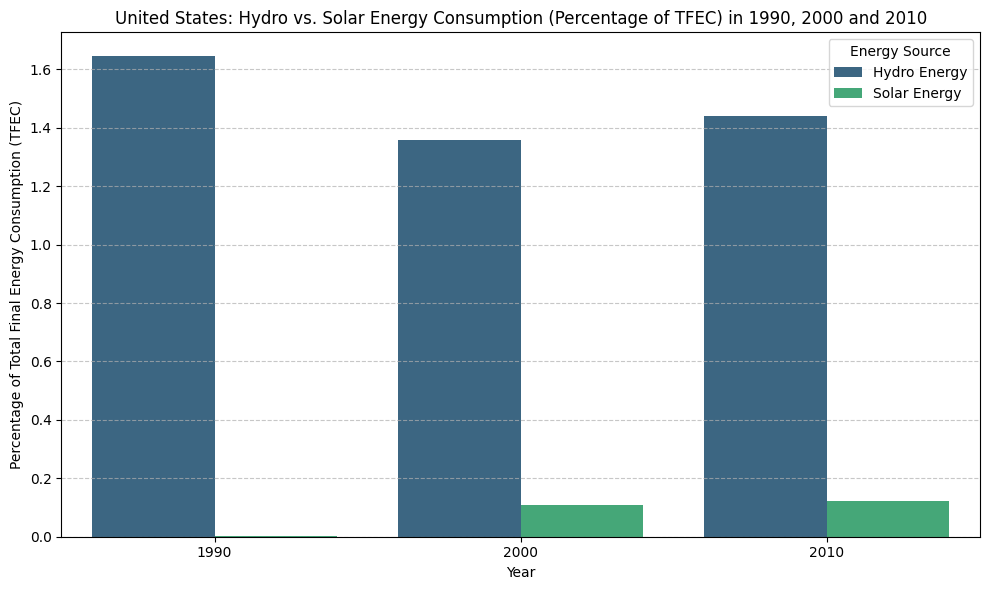

In [237]:
#Make the Plot for the data that I want to anaylze
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for United States and years 1990, 2000, 2010
us_energy_data = raw_df[
    (raw_df['country_name'] == 'United States') &
    (raw_df['yr'].isin([1990, 2000, 2010]))
][['yr', 'hydro_energy_consumption_tfec_pct', 'solar_energy_consumption_tfec_pct']]

# Melt the DataFrame for easier plotting
us_energy_melted = us_energy_data.melt(
    id_vars=['yr'],
    value_vars=['hydro_energy_consumption_tfec_pct', 'solar_energy_consumption_tfec_pct'],
    var_name='energy_source',
    value_name='percentage_tfec'
)

# Map column names for better readability on the plot
us_energy_melted['energy_source'] = us_energy_melted['energy_source'].map({
    'hydro_energy_consumption_tfec_pct': 'Hydro Energy',
    'solar_energy_consumption_tfec_pct': 'Solar Energy'
})

# Create the bar plot
fig = plt.figure(figsize=(10, 6))
sns.barplot(
    x='yr',
    y='percentage_tfec',
    hue='energy_source',
    data=us_energy_melted,
    palette='viridis'
)

plt.title('United States: Hydro vs. Solar Energy Consumption (Percentage of TFEC) in 1990, 2000 and 2010')
plt.xlabel('Year')
plt.ylabel('Percentage of Total Final Energy Consumption (TFEC)')
plt.legend(title='Energy Source')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Row/Column Droping

In [238]:
#Drop the cloums / rows that im not focusing on

columns_to_drop = ['access_electricity_total_pop_pct', 'access_electricity_rural_pop_pct', 'access_electricity_urban_pop_pct', 'renewable_energy_installed_capacity_gigawatts', 'total_installed_generation_capacity_gigawatts']

In [239]:
raw_df = raw_df.drop(columns=columns_to_drop, errors='ignore')

In [240]:
# List to store indices of rows to be dropped (if any)
rows_to_drop = []

In [241]:
selected_columns = [
    'country_name',
    'yr',
    'wind_energy_consumption_tfec_pct',
    'geothermal_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct',
    'total_final_energy_consumption_tfec'
]

# Filter the DataFrame for the selected countries and columns
# Assuming 'final_selected_countries' list from cell e43c3420 is the intended filter
filtered_energy_df = raw_df[raw_df['country_name'].isin(final_selected_countries)][selected_columns]

# Display the first few rows of the new DataFrame
display(filtered_energy_df.head(63))

,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,total_final_energy_consumption_tfec
0,Afghanistan,1990,NaN,0.0,0.000000,10.195503,9.661832e+03
1,Afghanistan,1991,NaN,0.0,0.000000,9.545578,9.229662e+03
2,Afghanistan,1992,NaN,0.0,0.000000,8.981214,8.012857e+03
3,Afghanistan,1993,NaN,0.0,0.000000,17.009797,9.402114e+03
4,Afghanistan,1994,NaN,NaN,NaN,16.760214,9.444700e+03
5,Afghanistan,1995,NaN,NaN,NaN,16.328298,9.528358e+03
6,Afghanistan,1996,NaN,NaN,NaN,13.798788,1.130921e+04
7,Afghanistan,1997,NaN,NaN,NaN,13.750519,1.142793e+04
8,Afghanistan,1998,NaN,NaN,NaN,13.002026,1.224226e+04
9,Afghanistan,1999,NaN,NaN,NaN,15.857293,1.027644e+04


## Convert columns to numeric, coercing non-numeric values to NaN

## Machine Learning Model: Predicting Energy Consumption

We will build a machine learning model to predict different energy consumption sources based on the country's income group and the year. This involves:

1.  **Data Preparation:** One-hot encoding categorical variables (`income_group`), selecting predictor (features) and response (targets) variables.
2.  **Model Training:** Using a `RandomForestRegressor` for its robustness and ability to capture non-linear relationships.
3.  **Model Evaluation:** Assessing the model's performance using metrics like R-squared, Mean Absolute Error (MAE), and Mean Squared Error (MSE).

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd

# Drop rows where 'income_group' is 'Not Classified' as they won't be useful for modeling
modeling_df = final_combined_df_with_gdp[final_combined_df_with_gdp['income_group'] != 'Not Classified'].copy()

# One-hot encode 'income_group'
modeling_df = pd.get_dummies(modeling_df, columns=['income_group'], drop_first=True)

# Define target energy consumption columns
target_energy_cols = [
    'solar_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct',
    'wind_energy_consumption_tfec_pct',
    'geothermal_energy_consumption_tfec_pct',
    'renewable_energy_consumption_tfec_pct'
]

# Define features (X) - Year and One-Hot Encoded Income Groups
# Ensure all income group columns are included even if they don't appear in every row due to `drop_first=True`
# and also include 'yr' (Year)
feature_cols = ['yr'] + [col for col in modeling_df.columns if 'income_group_' in col]
X = modeling_df[feature_cols]

print("Features (X) preview:")
display(X.head())

print("Target energy columns:")
print(target_energy_cols)

Features (X) preview:


,yr,income_group_Low Income Countries,income_group_Lower-middle-income Countries,income_group_Upper-middle-income Countries
0,1990,True,False,False
1,1991,True,False,False
2,1992,True,False,False
3,1993,True,False,False
4,1994,True,False,False


Target energy columns:
['solar_energy_consumption_tfec_pct', 'hydro_energy_consumption_tfec_pct', 'wind_energy_consumption_tfec_pct', 'geothermal_energy_consumption_tfec_pct', 'renewable_energy_consumption_tfec_pct']


### Log Transform the Target Variable

Applying a log transformation to the target variable, `renewable_energy_consumption_tfec_pct`, can help in several ways:

1.  **Reduce Skewness:** If the target variable has a skewed distribution (e.g., many small values and a few very large ones), a log transform can make it more symmetrical and closer to a normal distribution, which can improve the performance of some regression models.
2.  **Stabilize Variance:** It can help to stabilize the variance of the errors (homoscedasticity), which is an assumption for many statistical models.
3.  **Address Multiplicative Relationships:** Log transforms can convert multiplicative relationships into additive ones, making them easier for linear models to capture.

We will use `np.log1p` which calculates `log(1+x)`. This is preferred over `np.log` when the data might contain zero values, as `log(0)` is undefined. After making predictions, we will need to apply the inverse transformation (`np.expm1`) to bring the predictions back to the original scale.

In [35]:
import numpy as np

# Apply log transformation to the 'renewable_energy_consumption_tfec_pct' target variable
# Use np.log1p to handle potential zero values gracefully (log(1+x))
original_target_col = 'renewable_energy_consumption_tfec_pct'
log_transformed_target_col = 'log_renewable_energy_consumption_tfec_pct'

# Add the log-transformed column to modeling_df
modeling_df[log_transformed_target_col] = np.log1p(modeling_df[original_target_col])

print(f"Original target variable '{original_target_col}' transformed to '{log_transformed_target_col}'.")
print(f"Skewness before transformation: {modeling_df[original_target_col].skew():.4f}")
print(f"Skewness after transformation: {modeling_df[log_transformed_target_col].skew():.4f}")

# Update the target_energy_cols list to include the new log-transformed target
# We will only model the log-transformed renewable energy for now based on the previous context
target_energy_cols_log = [log_transformed_target_col]

# Also update feature_cols if needed, but for now it remains the same

print("\nUpdated target energy columns for modeling:")
print(target_energy_cols_log)


Original target variable 'renewable_energy_consumption_tfec_pct' transformed to 'log_renewable_energy_consumption_tfec_pct'.
Skewness before transformation: 0.4676
Skewness after transformation: -0.2693

Updated target energy columns for modeling:
['log_renewable_energy_consumption_tfec_pct']


### Training and Evaluating Regression Models for Each Energy Source

We will train a separate `RandomForestRegressor` for each energy consumption source. This allows us to understand how well income group and year predict the percentage of total final energy consumption from each source. After training, we will evaluate each model's performance.

- This will have the R-squared,


In [36]:
models = {}
metrics = {}

# We will only model the log-transformed renewable energy for now.
# The 'target_energy_cols_log' variable was set in the previous cell.
# If you wish to model other targets, you would uncomment or modify this.
targets_to_model = target_energy_cols_log # Use the log-transformed target

for target_col in targets_to_model:
    print(f"\n--- Modeling for: {target_col.replace('_', ' ').title()} ---")

    # Drop rows with NaN values in the current target column for this specific model training
    current_modeling_df = modeling_df.dropna(subset=[target_col])

    # Re-define X and y for the current target and filtered DataFrame
    X_current = current_modeling_df[feature_cols]
    y_current = current_modeling_df[target_col]

    if len(X_current) == 0:
        print(f"Not enough data to train a model for {target_col}.")
        continue

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_current, y_current, test_size=0.2, random_state=42)

    # Initialize and train the RandomForestRegressor model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    models[target_col] = model

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Store y_test and y_pred for the log-transformed target for later plotting
    if target_col == 'log_renewable_energy_consumption_tfec_pct':
        y_test_log = y_test
        y_pred_log = y_pred

    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    metrics[target_col] = {'R2': r2, 'MAE': mae, 'MSE': mse}

    print(f"  R-squared: {r2:.4f}")
    print(f"  Mean Absolute Error (MAE): {mae:.4f}")
    print(f"  Mean Squared Error (MSE): {mse:.4f}")

print("\n--- Summary of Model Metrics ---")
metrics_df = pd.DataFrame(metrics).T
display(metrics_df)


--- Modeling for: Log Renewable Energy Consumption Tfec Pct ---
  R-squared: 0.7851
  Mean Absolute Error (MAE): 0.3913
  Mean Squared Error (MSE): 0.2497

--- Summary of Model Metrics ---


,R2,MAE,MSE
log_renewable_energy_consumption_tfec_pct,0.785127,0.391303,0.24968


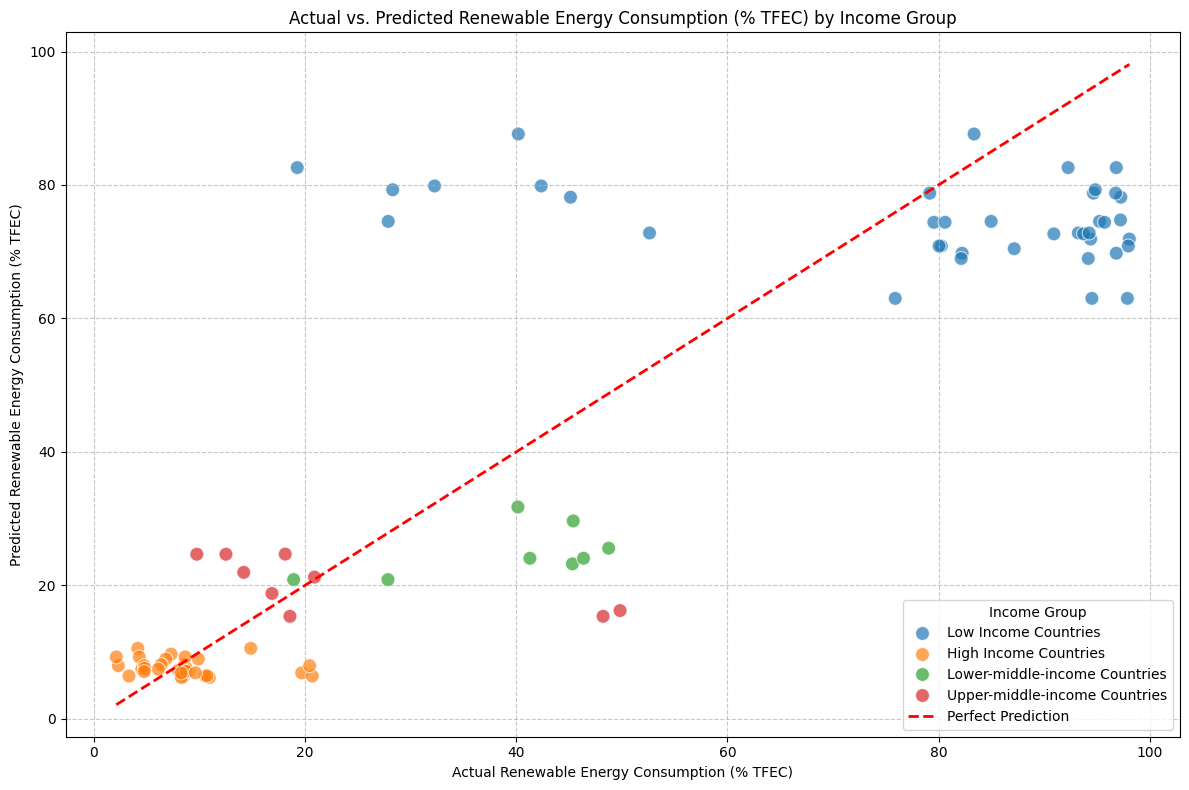

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure y_test_log and y_pred_log are available from the previous modeling step
# Inverse transform y_test_log and y_pred_log back to the original scale
y_test_original_scale = np.expm1(y_test_log)
y_pred_original_scale = np.expm1(y_pred_log)

# To get the original 'income_group' for plotting, we need to go back to a DataFrame
# that still contains the 'income_group' column and aligns with the indices of y_test_log.

# Step 1: Recreate the DataFrame that has the 'income_group' column before one-hot encoding
# and before the final split, but with the same rows filtered as 'modeling_df'
# (i.e., 'Not Classified' income groups removed).
df_pre_onehot_encoded = final_combined_df_with_gdp[final_combined_df_with_gdp['income_group'] != 'Not Classified'].copy()

# Step 2: Apply the same NaN dropping logic as 'current_modeling_df' (which was used for y_test_log)
# to this pre-one-hot DataFrame. This ensures that the rows in this DataFrame are exactly
# the ones from which y_test_log's indices are derived.
df_for_income_lookup = df_pre_onehot_encoded.dropna(subset=[original_target_col])

# Step 3: Use the index of y_test_log to retrieve the corresponding 'income_group' values
income_groups_for_plot = df_for_income_lookup.loc[y_test_log.index, 'income_group']

# Create a DataFrame for plotting that includes actual, predicted (original scale), and income_group
plot_df = pd.DataFrame({
    'Actual': y_test_original_scale,
    'Predicted': y_pred_original_scale,
    'income_group': income_groups_for_plot
})

# Create a scatter plot of Actual vs. Predicted values, colored by income_group
fig = plt.figure(figsize=(12, 8))
sns.scatterplot(x='Actual', y='Predicted', hue='income_group', data=plot_df, alpha=0.7, s=100) # Increased size for better visibility

plt.plot([plot_df['Actual'].min(), plot_df['Actual'].max()],
         [plot_df['Actual'].min(), plot_df['Actual'].max()],
         '--r', linewidth=2, label='Perfect Prediction') # Add a diagonal line for perfect prediction

plt.title('Actual vs. Predicted Renewable Energy Consumption (% TFEC) by Income Group')
plt.xlabel('Actual Renewable Energy Consumption (% TFEC)')
plt.ylabel('Predicted Renewable Energy Consumption (% TFEC)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Income Group') # Add legend title
plt.tight_layout()
plt.show()

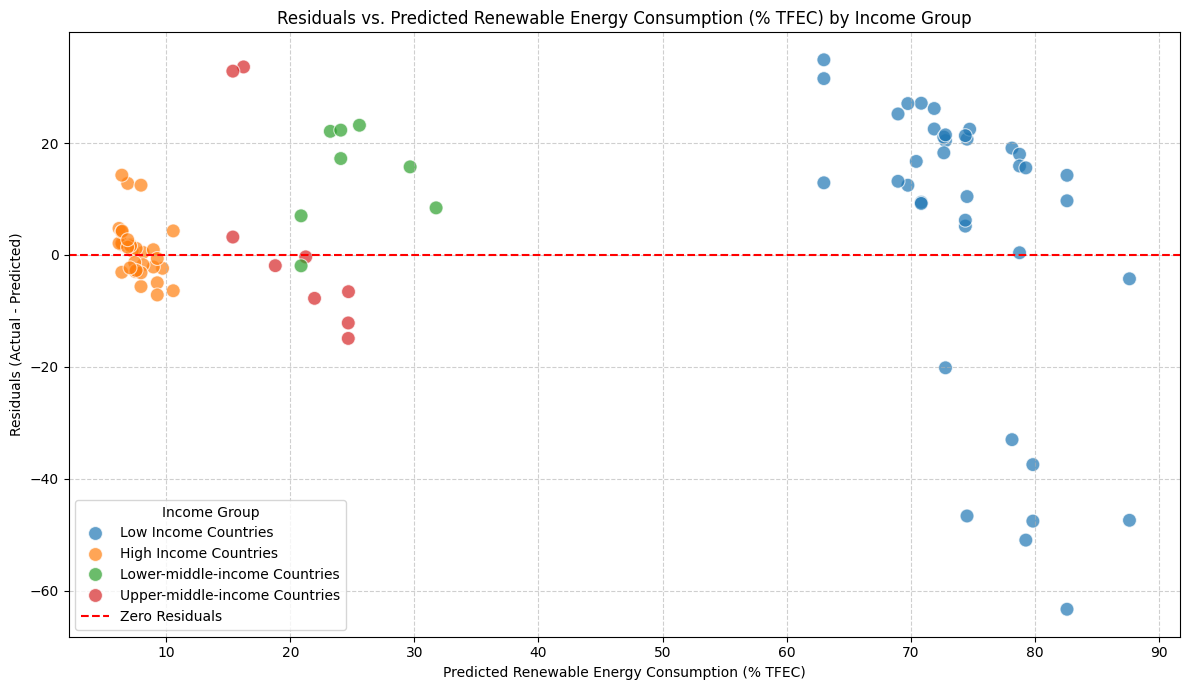

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals on the original scale
plot_df['Residuals'] = plot_df['Actual'] - plot_df['Predicted']

# Plot 1: Residuals vs. Predicted Values
fig_res_scatter = plt.figure(figsize=(12, 7))
sns.scatterplot(x='Predicted', y='Residuals', data=plot_df, hue='income_group', alpha=0.7, s=100)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residuals')
plt.title('Residuals vs. Predicted Renewable Energy Consumption (% TFEC) by Income Group')
plt.xlabel('Predicted Renewable Energy Consumption (% TFEC)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Income Group')
plt.tight_layout()
plt.show()

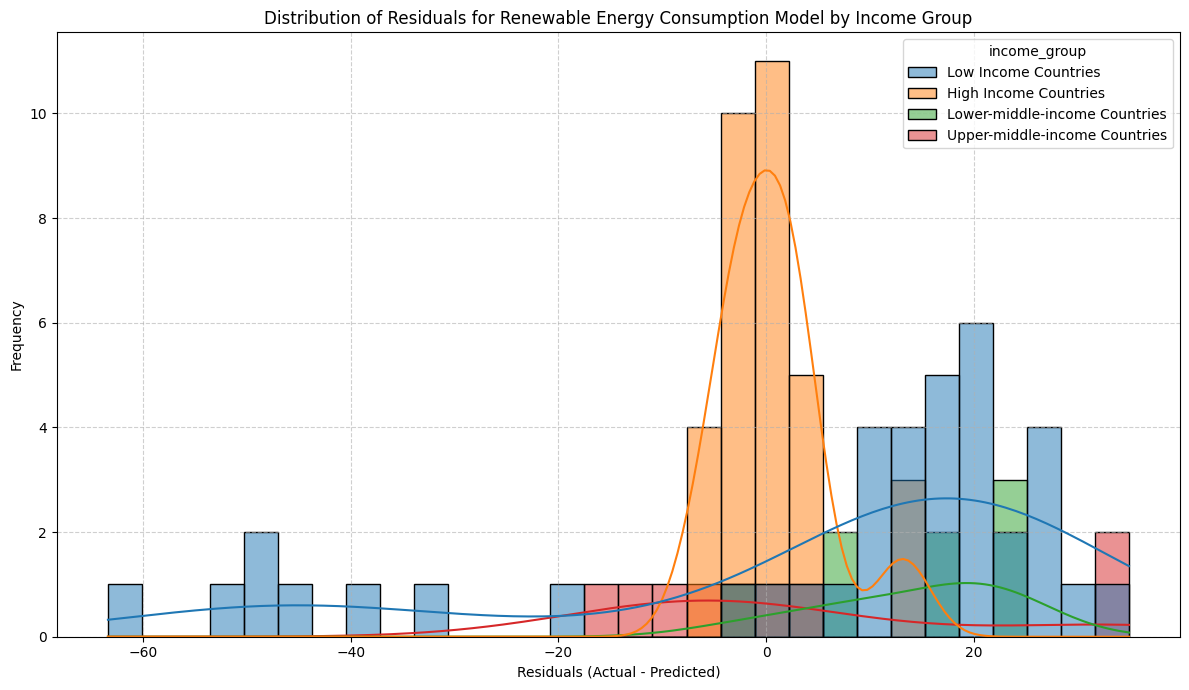

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 2: Histogram of Residuals by Income Group
fig_res_hist = plt.figure(figsize=(12, 7))
sns.histplot(data=plot_df, x='Residuals', hue='income_group', kde=True, bins=30)
plt.title('Distribution of Residuals for Renewable Energy Consumption Model by Income Group')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [242]:
# Create a copy of the DataFrame to apply numeric conversion
filtered_energy_df_numeric = filtered_energy_df.copy()

# Columns to convert to numeric
energy_cols_to_convert = [
    'wind_energy_consumption_tfec_pct',
    'geothermal_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct'
]

for col in energy_cols_to_convert:
    if col in filtered_energy_df_numeric.columns:
        filtered_energy_df_numeric[col] = pd.to_numeric(filtered_energy_df_numeric[col], errors='coerce')

# Display info to confirm data types in the new DataFrame
print("Data types after conversion in filtered_energy_df_numeric:")
display(filtered_energy_df_numeric.info())

Data types after conversion in filtered_energy_df_numeric:
<class 'pandas.core.frame.DataFrame'>
Index: 441 entries, 0 to 4976
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   country_name                            441 non-null    object 
 1   yr                                      441 non-null    int64  
 2   wind_energy_consumption_tfec_pct        242 non-null    float64
 3   geothermal_energy_consumption_tfec_pct  260 non-null    float64
 4   solar_energy_consumption_tfec_pct       301 non-null    float64
 5   hydro_energy_consumption_tfec_pct       419 non-null    float64
 6   total_final_energy_consumption_tfec     435 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 27.6+ KB


None

In [243]:
print("Missing values in filtered_energy_df_numeric after conversion:")
display(filtered_energy_df_numeric.isnull().sum())

Missing values in filtered_energy_df_numeric after conversion:


,0
country_name,0
yr,0
wind_energy_consumption_tfec_pct,199
geothermal_energy_consumption_tfec_pct,181
solar_energy_consumption_tfec_pct,140
hydro_energy_consumption_tfec_pct,22
total_final_energy_consumption_tfec,6


## Consolidated Data Preparation

To ensure all data is loaded and prepared consistently and efficiently, we will consolidate the loading and processing of income group data and GDP per capita data into a single, comprehensive block. This will define the `classify_income_group_from_df` function, create `final_combined_energy_df_numeric`, and then merge it with the processed GDP data to form `final_combined_df_with_gdp`.

In [64]:
import pandas as pd

# --- Define the classify_income_group_from_df function (defined once) ---
def classify_income_group_from_df(country_name, year, income_df):
    country_year_data = income_df[(income_df['country_name'] == country_name) & (income_df['yr'] == year)]

    if not country_year_data.empty:
        detailed_group = country_year_data['income_group'].iloc[0]

        if 'High-income' in detailed_group:
            return 'High Income Countries'
        elif 'Lower-middle-income' in detailed_group:
            return 'Lower-middle-income Countries'
        elif 'Upper-middle-income' in detailed_group:
            return 'Upper-middle-income Countries'
        elif 'Low-income' in detailed_group:
            return 'Low Income Countries'
        else:
            return 'Not Classified'
    else:
        return 'Not Classified'

# --- Load and Prepare Income Group Data (done once) ---
Income_URL = "https://raw.githubusercontent.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/refs/heads/main/world-bank-income-groups.csv"
try:
    income_group_df = pd.read_csv(Income_URL)
    print("Income data loaded successfully.")
except Exception as e:
    print(f"Error loading income data: {e}")
    income_group_df = pd.DataFrame() # Create empty DataFrame to avoid errors

income_group_df = income_group_df.rename(columns={'Entity': 'country_name', 'Year': 'yr', "World Bank's income classification": 'income_group'})
income_group_df = income_group_df.drop(columns=['Code'], errors='ignore')
income_group_df['yr'] = income_group_df['yr'].astype(int)
income_group_df['country_name'] = income_group_df['country_name'].str.strip()
income_group_df = income_group_df[income_group_df['income_group'] != 'Not Classified'].copy() # Filter 'Not Classified' early

print("Income Group DataFrame prepared.")

# --- Prepare Energy Consumption Data ---
# Define the comprehensive list of countries
final_selected_countries = [
    'Afghanistan', 'Australia', 'Brazil', 'Burundi', 'Canada', 'Chad', 'China',
    'Egypt', 'Ethiopia', 'France', 'Germany', 'India', 'Indonesia', 'Japan',
    'Madagascar', 'Malawi', 'Mexico', 'Niger', 'South Africa', 'Spain', 'Turkey',
    'United States'
]

# Use the same selected columns for energy consumption data
final_selected_columns = [
    'country_name',
    'yr',
    'wind_energy_consumption_tfec_pct',
    'geothermal_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct',
    'renewable_energy_consumption_tfec_pct',
    'total_final_energy_consumption_tfec'
]

# Filter the raw_df for this comprehensive set of countries and columns
# Assuming raw_df is already loaded from an earlier cell (e.g., TXrjOqnon-6G)
final_combined_energy_df = raw_df[raw_df['country_name'].isin(final_selected_countries)][final_selected_columns].copy()

# Create a copy for numeric conversion and imputation
final_combined_energy_df_numeric = final_combined_energy_df.copy()

# Columns to convert to numeric
energy_cols_to_convert_final = [
    'wind_energy_consumption_tfec_pct',
    'geothermal_energy_consumption_tfec_pct',
    'solar_energy_consumption_tfec_pct',
    'hydro_energy_consumption_tfec_pct',
    'renewable_energy_consumption_tfec_pct',
    'total_final_energy_consumption_tfec'
]

# Convert to numeric, coercing non-numeric values to NaN
for col in energy_cols_to_convert_final:
    if col in final_combined_energy_df_numeric.columns:
        final_combined_energy_df_numeric[col] = pd.to_numeric(final_combined_energy_df_numeric[col], errors='coerce')

# Fill missing values using the same imputation method:
# 1. Country-specific median
# 2. Overall column median (if any NaNs remain)
for col in energy_cols_to_convert_final:
    if col in final_combined_energy_df_numeric.columns:
        final_combined_energy_df_numeric[col] = final_combined_energy_df_numeric.groupby('country_name')[col].transform(lambda x: x.fillna(x.median()))
        if final_combined_energy_df_numeric[col].isnull().any():
            global_median = final_combined_energy_df_numeric[col].median()
            final_combined_energy_df_numeric[col] = final_combined_energy_df_numeric[col].fillna(global_median)

# Apply the classify_income_group_from_df function
final_combined_energy_df_numeric['income_group'] = final_combined_energy_df_numeric.apply(
    lambda row: classify_income_group_from_df(row['country_name'], row['yr'], income_group_df), axis=1
)

print("Final Combined Energy DataFrame with imputed values and Income Groups created.")

# --- Load and Prepare GDP Data (done once) ---
GDPPerCapital_URL = "https://raw.githubusercontent.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/refs/heads/main/GDP%20per%20capita%20(current%20US%24).csv"
gdpPerCapital_df_raw = pd.read_csv(GDPPerCapital_URL)

gdpPerCapital_df_raw['Series Name'] = gdpPerCapital_df_raw['Series Name'].str.strip()
gdpPerCapital_df_raw_gdp_only = gdpPerCapital_df_raw[gdpPerCapital_df_raw['Series Name'] == 'GDP per capita (current US$)'].copy()
year_columns = [col for col in gdpPerCapital_df_raw_gdp_only.columns if '[YR' in col]

gdpPerCapital_df = gdpPerCapital_df_raw_gdp_only.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=year_columns,
    var_name='yr_full',
    value_name='gdp_usd'
)

gdpPerCapital_df['yr'] = gdpPerCapital_df['yr_full'].apply(lambda x: int(x.split(' ')[0]))
gdpPerCapital_df = gdpPerCapital_df.rename(columns={'Country Name': 'country_name'})

# Country name mapping for consistency
country_name_mapping = {
    'Egypt, Arab Rep.': 'Egypt',
    'Iran, Islamic Rep.': 'Iran',
    'Korea, Rep.': 'South Korea',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Russian Federation': 'Russia',
    'Slovak Republic': 'Slovakia',
    'Taiwan, China': 'Taiwan',
    'Venezuela, RB': 'Venezuela',
    'Yemen, Rep.': 'Yemen',
    'Hong Kong SAR, China': 'Hong Kong',
    'Bahamas, The': 'Bahamas'
}
gdpPerCapital_df['country_name'] = gdpPerCapital_df['country_name'].replace(country_name_mapping)

# Filter out non-country entities from gdpPerCapital_df
non_country_entities_to_filter = [
    'High income', 'High income: nonOECD', 'High income: OECD',
    'Low & middle income', 'Low income', 'Lower middle income',
    'Middle income', 'Upper middle income',
    'Latin America and Caribbean', 'Eastern Asia (including Japan)',
    'Eastern Asia (not including Japan)', 'Eastern Europe', 'Europe',
    'Northern Africa', 'Nothern America', 'Oceania',
    'Oceania (not including Australia and New Zealand)', 'South Eastern Asia',
    'Southern Asia', 'Sub-Saharan Africa', 'Western Asia', 'World',
    'Channel Islands', 'American Samoa', 'Andorra', 'Aruba', 'Bermuda',
    'British Virgin Islands', 'Cayman Islands', 'Cook Islands', 'Curacao',
    'Dominica', 'Faeroe Islands', 'Falkland Islands', 'French Guyana',
    'French Polynesia', 'Gibraltar', 'Greenland', 'Guadeloupe', 'Guam',
    'Isle of Man', 'Kiribati', 'Liechtenstein', 'Marshall Islands',
    'Martinique', 'Mayotte', 'Micronesia, Fed. Sts.', 'Monaco', 'Montserrat',
    'New Caledonia', 'Netherlands Antilles', 'Northern Mariana Islands', 'Palau',
    'Puerto Rico', 'Qatar', 'Reunion', 'Saint Pierre et Miquelon', 'Samoa',
    'San Marino', 'Sao Tome and Principe', 'Seychelles', 'Sint Maarten (Dutch part)',
    'Solomon Islands', 'St. Kitts and Nevis', 'St. Lucia', 'St. Martin (French part)',
    'St. Vincent and the Grenadines', 'Suriname', 'Swaziland', 'Timor-Leste', 'Togo',
    'Tonga', 'Turks and Caicos Islands', 'Tuvalu', 'Virgin Islands (U.S.)',
    'Western Sahara', 'Kosovo', 'Lao PDR', 'Macao SAR, China', 'South Sudan',
    'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire"
]
gdpPerCapital_df = gdpPerCapital_df[~gdpPerCapital_df['country_name'].isin(non_country_entities_to_filter)].copy()

gdpPerCapital_df = gdpPerCapital_df[['country_name', 'yr', 'gdp_usd']].copy()
gdpPerCapital_df['gdp_usd'] = pd.to_numeric(gdpPerCapital_df['gdp_usd'], errors='coerce')
gdpPerCapital_df.dropna(subset=['gdp_usd', 'country_name'], inplace=True)

gdpPerCapital_df = gdpPerCapital_df[gdpPerCapital_df['yr'].isin([1990, 2000, 2010])].copy()
gdpPerCapital_df = gdpPerCapital_df[gdpPerCapital_df['country_name'].isin(final_selected_countries)].copy()

print("GDP Data prepared.")

# --- Merge Energy and GDP Data and Impute GDP (done once) ---
final_combined_df_with_gdp = pd.merge(
    final_combined_energy_df_numeric,
    gdpPerCapital_df,
    on=['country_name', 'yr'],
    how='left'
)

# Impute missing gdp_usd values
final_combined_df_with_gdp['gdpPerCapital_usd'] = final_combined_df_with_gdp.groupby('country_name')['gdp_usd'].transform(lambda x: x.fillna(x.median()))
if final_combined_df_with_gdp['gdpPerCapital_usd'].isnull().any():
    global_gdp_median = final_combined_df_with_gdp['gdpPerCapital_usd'].median()
    final_combined_df_with_gdp['gdpPerCapital_usd'] = final_combined_df_with_gdp['gdpPerCapital_usd'].fillna(global_gdp_median)

print("Final combined DataFrame with GDP created successfully.")

# --- Display results ---
print("\n--- Final Combined DataFrame with imputed values and Income Groups ---")
display(final_combined_df_with_gdp.head())

print("\n--- Missing values in final_combined_df_with_gdp after imputation ---")
display(final_combined_df_with_gdp.isnull().sum())

Income data loaded successfully.
Income Group DataFrame prepared.
Final Combined Energy DataFrame with imputed values and Income Groups created.
GDP Data prepared.
Final combined DataFrame with GDP created successfully.

--- Final Combined DataFrame with imputed values and Income Groups ---


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group,gdp_usd,gdpPerCapital_usd
0,Afghanistan,1990,0.00725,0.0,0.0,10.195503,42.362380,9661.83210,Low Income Countries,NaN,367.776248
1,Afghanistan,1991,0.00725,0.0,0.0,9.545578,44.062889,9229.66245,Low Income Countries,NaN,367.776248
2,Afghanistan,1992,0.00725,0.0,0.0,8.981214,50.784306,8012.85660,Low Income Countries,NaN,367.776248
3,Afghanistan,1993,0.00725,0.0,0.0,17.009797,54.716233,9402.11415,Low Income Countries,NaN,367.776248
4,Afghanistan,1994,0.00725,0.0,0.0,16.760214,56.525081,9444.70035,Low Income Countries,NaN,367.776248



--- Missing values in final_combined_df_with_gdp after imputation ---


,0
country_name,0
yr,0
wind_energy_consumption_tfec_pct,0
geothermal_energy_consumption_tfec_pct,0
solar_energy_consumption_tfec_pct,0
hydro_energy_consumption_tfec_pct,0
renewable_energy_consumption_tfec_pct,0
total_final_energy_consumption_tfec,0
income_group,0
gdp_usd,382


In [246]:
# Re-run GDP data processing to include the newly selected countries
import pandas as pd

gdpPerCapital_df_raw = pd.read_csv(GDPPerCapital_URL)

# Strip whitespace from 'Series Name' to ensure accurate matching
gdpPerCapital_df_raw['Series Name'] = gdpPerCapital_df_raw['Series Name'].str.strip()

# Filter for the relevant series: GDP per capita (current US$)
gdpPerCapital_df_raw_gdp_only = gdpPerCapital_df_raw[gdpPerCapital_df_raw['Series Name'] == 'GDP per capita (current US$)'].copy()

# Identify year columns (e.g., '1990 [YR1990]', '1991 [YR1991]', etc.)
year_columns = [col for col in gdpPerCapital_df_raw_gdp_only.columns if '[YR' in col]

# Melt the DataFrame to transform year columns into rows
gdpPerCapital_df = gdpPerCapital_df_raw_gdp_only.melt(
    id_vars=['Country Name', 'Country Code'], # Keep country identifiers
    value_vars=year_columns,
    var_name='yr_full',
    value_name='gdp_usd'
)

# Extract the numeric year from 'yr_full'
gdpPerCapital_df['yr'] = gdpPerCapital_df['yr_full'].apply(lambda x: int(x.split(' ')[0]))

# Rename 'Country Name' for consistency with energy dataframe
gdpPerCapital_df = gdpPerCapital_df.rename(columns={'Country Name': 'country_name'})

# Apply the same country name mapping as used for raw_df
country_name_mapping = {
    'Egypt, Arab Rep.': 'Egypt',
    'Iran, Islamic Rep.': 'Iran',
    'Korea, Rep.': 'South Korea',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Russian Federation': 'Russia',
    'Slovak Republic': 'Slovakia',
    'Taiwan, China': 'Taiwan',
    'Venezuela, RB': 'Venezuela',
    'Yemen, Rep.': 'Yemen',
    'Hong Kong SAR, China': 'Hong Kong',
    'Bahamas, The': 'Bahamas'
}
gdpPerCapital_df['country_name'] = gdpPerCapital_df['country_name'].replace(country_name_mapping)

# Filter out non-country entities from gdpPerCapital_df as well
non_country_entities_to_filter = [
    'High income', 'High income: nonOECD', 'High income: OECD',
    'Low & middle income', 'Low income', 'Lower middle income',
    'Middle income', 'Upper middle income',
    'Latin America and Caribbean', 'Eastern Asia (including Japan)',
    'Eastern Asia (not including Japan)', 'Eastern Europe', 'Europe',
    'Northern Africa', 'Nothern America', 'Oceania',
    'Oceania (not including Australia and New Zealand)', 'South Eastern Asia',
    'Southern Asia', 'Sub-Saharan Africa', 'Western Asia', 'World',
    'Channel Islands', 'American Samoa', 'Andorra', 'Aruba', 'Bermuda',
    'British Virgin Islands', 'Cayman Islands', 'Cook Islands', 'Curacao',
    'Dominica', 'Faeroe Islands', 'Falkland Islands', 'French Guyana',
    'French Polynesia', 'Gibraltar', 'Greenland', 'Guadeloupe', 'Guam',
    'Isle of Man', 'Kiribati', 'Liechtenstein', 'Marshall Islands',
    'Martinique', 'Mayotte', 'Micronesia, Fed. Sts.', 'Monaco', 'Montserrat',
    'New Caledonia', 'Netherlands Antilles', 'Northern Mariana Islands', 'Palau',
    'Puerto Rico', 'Qatar', 'Reunion', 'Saint Pierre et Miquelon', 'Samoa',
    'San Marino', 'Sao Tome and Principe', 'Seychelles', 'Sint Maarten (Dutch part)',
    'Solomon Islands', 'St. Kitts and Nevis', 'St. Lucia', 'St. Martin (French part)',
    'St. Vincent and the Grenadines', 'Suriname', 'Swaziland', 'Timor-Leste', 'Togo',
    'Tonga', 'Turks and Caicos Islands', 'Tuvalu', 'Virgin Islands (U.S.)',
    'Western Sahara', 'Kosovo', 'Lao PDR', 'Macao SAR, China', 'South Sudan',
    'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire"
]
gdpPerCapital_df = gdpPerCapital_df[~gdpPerCapital_df['country_name'].isin(non_country_entities_to_filter)].copy()

# Select final columns and convert 'gdp_usd' to numeric
gdpPerCapital_df = gdpPerCapital_df[['country_name', 'yr', 'gdp_usd']].copy()
gdpPerCapital_df['gdp_usd'] = pd.to_numeric(gdpPerCapital_df['gdp_usd'], errors='coerce')

# Drop rows where GDP is NaN after conversion or if country_name is missing
gdpPerCapital_df.dropna(subset=['gdp_usd', 'country_name'], inplace=True)

# Filter for years 1990, 2000, 2010 as per problem description context
gdpPerCapital_df = gdpPerCapital_df[gdpPerCapital_df['yr'].isin([1990, 2000, 2010])].copy()

# Filter gdpPerCapital_df to include only the final_selected_countries to match the energy dataframe
# This list was updated in e43c3420, so use the global variable 'final_selected_countries'
gdpPerCapital_df = gdpPerCapital_df[gdpPerCapital_df['country_name'].isin(final_selected_countries)].copy()


print("--- GDP Data Preview ---")
display(gdpPerCapital_df.head())

print("--- GDP Data Info ---")
display(gdpPerCapital_df.info())

print("--- Missing values in GDP Data ---")
display(gdpPerCapital_df.isnull().sum())

--- GDP Data Preview ---


,country_name,yr,gdp_usd
10,Australia,1990,18273.561530
26,Brazil,1990,2581.141874
31,Burundi,1990,202.629446
35,Canada,1990,21525.861140
38,Chad,1990,290.599045


--- GDP Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 10 to 4976
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  62 non-null     object 
 1   yr            62 non-null     int64  
 2   gdp_usd       62 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.9+ KB


None

--- Missing values in GDP Data ---


,0
country_name,0
yr,0
gdp_usd,0


In [247]:
# Merge final_combined_energy_df_numeric with gdpPerCapital_df to create final_combined_df_with_gdp
# We'll use a left merge to keep all energy data and add GDP information where available
final_combined_df_with_gdp = pd.merge(
    final_combined_energy_df_numeric,
    gdpPerCapital_df,
    on=['country_name', 'yr'],
    how='left'
)

# Impute missing gdp_usd values
# 1. Fill with country-specific median
final_combined_df_with_gdp['gdpPerCapital_usd'] = final_combined_df_with_gdp.groupby('country_name')['gdp_usd'].transform(lambda x: x.fillna(x.median()))

# 2. Fill any remaining NaNs with the overall median
if final_combined_df_with_gdp['gdpPerCapital_usd'].isnull().any():
    global_gdp_median = final_combined_df_with_gdp['gdpPerCapital_usd'].median()
    final_combined_df_with_gdp['gdpPerCapital_usd'] = final_combined_df_with_gdp['gdpPerCapital_usd'].fillna(global_gdp_median)

print(f"Shape after merging with GDP data: {final_combined_df_with_gdp.shape}")
print("--- Sample of merged DataFrame with GDP ---")
display(final_combined_df_with_gdp.head())

print("--- Missing values after GDP merge and imputation ---")
display(final_combined_df_with_gdp.isnull().sum())

Shape after merging with GDP data: (441, 11)
--- Sample of merged DataFrame with GDP ---


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group,gdp_usd,gdpPerCapital_usd
0,Afghanistan,1990,0.00725,0.0,0.0,10.195503,42.362380,9661.83210,Not Classified,NaN,367.776248
1,Afghanistan,1991,0.00725,0.0,0.0,9.545578,44.062889,9229.66245,Not Classified,NaN,367.776248
2,Afghanistan,1992,0.00725,0.0,0.0,8.981214,50.784306,8012.85660,Not Classified,NaN,367.776248
3,Afghanistan,1993,0.00725,0.0,0.0,17.009797,54.716233,9402.11415,Not Classified,NaN,367.776248
4,Afghanistan,1994,0.00725,0.0,0.0,16.760214,56.525081,9444.70035,Not Classified,NaN,367.776248


--- Missing values after GDP merge and imputation ---


,0
country_name,0
yr,0
wind_energy_consumption_tfec_pct,0
geothermal_energy_consumption_tfec_pct,0
solar_energy_consumption_tfec_pct,0
hydro_energy_consumption_tfec_pct,0
renewable_energy_consumption_tfec_pct,0
total_final_energy_consumption_tfec,0
income_group,0
gdp_usd,382


In [248]:
# Re-run GDP data processing to include the newly selected countries
import pandas as pd

gdpPerCapital_df_raw = pd.read_csv(GDPPerCapital_URL)

# Strip whitespace from 'Series Name' to ensure accurate matching
gdpPerCapital_df_raw['Series Name'] = gdpPerCapital_df_raw['Series Name'].str.strip()

# Filter for the relevant series: GDP per capita (current US$)
gdpPerCapital_df_raw_gdp_only = gdpPerCapital_df_raw[gdpPerCapital_df_raw['Series Name'] == 'GDP per capita (current US$)'].copy()

# Identify year columns (e.g., '1990 [YR1990]', '1991 [YR1991]', etc.)
year_columns = [col for col in gdpPerCapital_df_raw_gdp_only.columns if '[YR' in col]

# Melt the DataFrame to transform year columns into rows
gdpPerCapital_df = gdpPerCapital_df_raw_gdp_only.melt(
    id_vars=['Country Name', 'Country Code'], # Keep country identifiers
    value_vars=year_columns,
    var_name='yr_full',
    value_name='gdp_usd'
)

# Extract the numeric year from 'yr_full'
gdpPerCapital_df['yr'] = gdpPerCapital_df['yr_full'].apply(lambda x: int(x.split(' ')[0]))

# Rename 'Country Name' for consistency with energy dataframe
gdpPerCapital_df = gdpPerCapital_df.rename(columns={'Country Name': 'country_name'})

# Apply the same country name mapping as used for raw_df
country_name_mapping = {
    'Egypt, Arab Rep.': 'Egypt',
    'Iran, Islamic Rep.': 'Iran',
    'Korea, Rep.': 'South Korea',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Russian Federation': 'Russia',
    'Slovak Republic': 'Slovakia',
    'Taiwan, China': 'Taiwan',
    'Venezuela, RB': 'Venezuela',
    'Yemen, Rep.': 'Yemen',
    'Hong Kong SAR, China': 'Hong Kong',
    'Bahamas, The': 'Bahamas'
}
gdpPerCapital_df['country_name'] = gdpPerCapital_df['country_name'].replace(country_name_mapping)

# Filter out non-country entities from gdpPerCapital_df as well
non_country_entities_to_filter = [
    'High income', 'High income: nonOECD', 'High income: OECD',
    'Low & middle income', 'Low income', 'Lower middle income',
    'Middle income', 'Upper middle income',
    'Latin America and Caribbean', 'Eastern Asia (including Japan)',
    'Eastern Asia (not including Japan)', 'Eastern Europe', 'Europe',
    'Northern Africa', 'Nothern America', 'Oceania',
    'Oceania (not including Australia and New Zealand)', 'South Eastern Asia',
    'Southern Asia', 'Sub-Saharan Africa', 'Western Asia', 'World',
    'Channel Islands', 'American Samoa', 'Andorra', 'Aruba', 'Bermuda',
    'British Virgin Islands', 'Cayman Islands', 'Cook Islands', 'Curacao',
    'Dominica', 'Faeroe Islands', 'Falkland Islands', 'French Guyana',
    'French Polynesia', 'Gibraltar', 'Greenland', 'Guadeloupe', 'Guam',
    'Isle of Man', 'Kiribati', 'Liechtenstein', 'Marshall Islands',
    'Martinique', 'Mayotte', 'Micronesia, Fed. Sts.', 'Monaco', 'Montserrat',
    'New Caledonia', 'Netherlands Antilles', 'Northern Mariana Islands', 'Palau',
    'Puerto Rico', 'Qatar', 'Reunion', 'Saint Pierre et Miquelon', 'Samoa',
    'San Marino', 'Sao Tome and Principe', 'Seychelles', 'Sint Maarten (Dutch part)',
    'Solomon Islands', 'St. Kitts and Nevis', 'St. Lucia', 'St. Martin (French part)',
    'St. Vincent and the Grenadines', 'Suriname', 'Swaziland', 'Timor-Leste', 'Togo',
    'Tonga', 'Turks and Caicos Islands', 'Tuvalu', 'Virgin Islands (U.S.)',
    'Western Sahara', 'Kosovo', 'Lao PDR', 'Macao SAR, China', 'South Sudan',
    'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire"
]
gdpPerCapital_df = gdpPerCapital_df[~gdpPerCapital_df['country_name'].isin(non_country_entities_to_filter)].copy()

# Select final columns and convert 'gdp_usd' to numeric
gdpPerCapital_df = gdpPerCapital_df[['country_name', 'yr', 'gdp_usd']].copy()
gdpPerCapital_df['gdp_usd'] = pd.to_numeric(gdpPerCapital_df['gdp_usd'], errors='coerce')

# Drop rows where GDP is NaN after conversion or if country_name is missing
gdpPerCapital_df.dropna(subset=['gdp_usd', 'country_name'], inplace=True)

# Filter for years 1990, 2000, 2010 as per problem description context
gdpPerCapital_df = gdpPerCapital_df[gdpPerCapital_df['yr'].isin([1990, 2000, 2010])].copy()

# Filter gdpPerCapital_df to include only the final_selected_countries to match the energy dataframe
# This list was updated in e43c3420, so use the global variable 'final_selected_countries'
gdpPerCapital_df = gdpPerCapital_df[gdpPerCapital_df['country_name'].isin(final_selected_countries)].copy()


print("--- GDP Data Preview ---")
display(gdpPerCapital_df.head())

print("--- GDP Data Info ---")
display(gdpPerCapital_df.info())

print("--- Missing values in GDP Data ---")
display(gdpPerCapital_df.isnull().sum())

--- GDP Data Preview ---


,country_name,yr,gdp_usd
10,Australia,1990,18273.561530
26,Brazil,1990,2581.141874
31,Burundi,1990,202.629446
35,Canada,1990,21525.861140
38,Chad,1990,290.599045


--- GDP Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 10 to 4976
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  62 non-null     object 
 1   yr            62 non-null     int64  
 2   gdp_usd       62 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.9+ KB


None

--- Missing values in GDP Data ---


,0
country_name,0
yr,0
gdp_usd,0


In [249]:
# Merge final_combined_energy_df_numeric with gdpPerCapital_df to create final_combined_df_with_gdp
# We'll use a left merge to keep all energy data and add GDP information where available
final_combined_df_with_gdp = pd.merge(
    final_combined_energy_df_numeric,
    gdpPerCapital_df,
    on=['country_name', 'yr'],
    how='left'
)

# Impute missing gdp_usd values
# 1. Fill with country-specific median
final_combined_df_with_gdp['gdpPerCapital_usd'] = final_combined_df_with_gdp.groupby('country_name')['gdp_usd'].transform(lambda x: x.fillna(x.median()))

# 2. Fill any remaining NaNs with the overall median
if final_combined_df_with_gdp['gdpPerCapital_usd'].isnull().any():
    global_gdp_median = final_combined_df_with_gdp['gdpPerCapital_usd'].median()
    final_combined_df_with_gdp['gdpPerCapital_usd'] = final_combined_df_with_gdp['gdpPerCapital_usd'].fillna(global_gdp_median)

print(f"Shape after merging with GDP data: {final_combined_df_with_gdp.shape}")
print("--- Sample of merged DataFrame with GDP ---")
display(final_combined_df_with_gdp.head())

print("--- Missing values after GDP merge and imputation ---")
display(final_combined_df_with_gdp.isnull().sum())

Shape after merging with GDP data: (441, 11)
--- Sample of merged DataFrame with GDP ---


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group,gdp_usd,gdpPerCapital_usd
0,Afghanistan,1990,0.00725,0.0,0.0,10.195503,42.362380,9661.83210,Not Classified,NaN,367.776248
1,Afghanistan,1991,0.00725,0.0,0.0,9.545578,44.062889,9229.66245,Not Classified,NaN,367.776248
2,Afghanistan,1992,0.00725,0.0,0.0,8.981214,50.784306,8012.85660,Not Classified,NaN,367.776248
3,Afghanistan,1993,0.00725,0.0,0.0,17.009797,54.716233,9402.11415,Not Classified,NaN,367.776248
4,Afghanistan,1994,0.00725,0.0,0.0,16.760214,56.525081,9444.70035,Not Classified,NaN,367.776248


--- Missing values after GDP merge and imputation ---


,0
country_name,0
yr,0
wind_energy_consumption_tfec_pct,0
geothermal_energy_consumption_tfec_pct,0
solar_energy_consumption_tfec_pct,0
hydro_energy_consumption_tfec_pct,0
renewable_energy_consumption_tfec_pct,0
total_final_energy_consumption_tfec,0
income_group,0
gdp_usd,382


In [250]:
print("--- Direct test of classify_income_group_from_df for problematic countries (Year 2000) ---")

problematic_countries = {
    'India': 'Middle Income',
    'Brazil': 'Middle Income',
    'Mexico': 'Middle Income',
    'South Africa': 'Middle Income'
}

check_year = 2000

for country, expected_group in problematic_countries.items():
    classified_group = classify_income_group_from_df(country, check_year, income_group_df)
    status = "CORRECT" if classified_group == expected_group else f"INCORRECT (Function returned: {classified_group})"
    print(f"  {country} (Expected: {expected_group}): {status}")

--- Direct test of classify_income_group_from_df for problematic countries (Year 2000) ---
  India (Expected: Middle Income): INCORRECT (Function returned: Not Classified)
  Brazil (Expected: Middle Income): INCORRECT (Function returned: Upper-middle-income Countries)
  Mexico (Expected: Middle Income): INCORRECT (Function returned: Upper-middle-income Countries)
  South Africa (Expected: Middle Income): INCORRECT (Function returned: Upper-middle-income Countries)


In [251]:
print(final_combined_energy_df_numeric.columns.tolist())

['country_name', 'yr', 'wind_energy_consumption_tfec_pct', 'geothermal_energy_consumption_tfec_pct', 'solar_energy_consumption_tfec_pct', 'hydro_energy_consumption_tfec_pct', 'renewable_energy_consumption_tfec_pct', 'total_final_energy_consumption_tfec', 'income_group']


### Hypothesis Test: ANOVA for Renewable Energy Consumption WITHIN Income Groups

We will perform ANOVA tests to determine if there are significant differences in `renewable_energy_consumption_tfec_pct` among countries *within* each income group (High, Middle, and Low).

In [46]:
from scipy.stats import f_oneway

# Get unique income groups from the dataframe
income_groups_for_anova = final_combined_energy_df_numeric['income_group'].unique()

for income_group_name in income_groups_for_anova:
    print(f"\n--- ANOVA for Renewable Energy Consumption in {income_group_name} ---")

    # Filter data for the current income group
    current_income_group_df = final_combined_energy_df_numeric[final_combined_energy_df_numeric['income_group'] == income_group_name]

    # Collect data for each country within this income group
    country_groups = []
    for country in current_income_group_df['country_name'].unique():
        country_data = current_income_group_df[current_income_group_df['country_name'] == country]['renewable_energy_consumption_tfec_pct'].dropna()
        if len(country_data) > 0:
            country_groups.append(country_data)

    # Perform ANOVA if there's enough data (at least two countries with data)
    if len(country_groups) > 1 and all(len(g) > 0 for g in country_groups):
        f_stat, p_val = f_oneway(*country_groups)
        print(f"F-statistic ({income_group_name}): {f_stat:.2f}")
        print(f"P-value ({income_group_name}): {p_val:.10e}")
        if p_val < 0.05:
            print(f"Conclusion: There is a significant difference in renewable energy consumption among countries within {income_group_name} (p < 0.05).")
        else:
            print(f"Conclusion: There is no significant difference in renewable energy consumption among countries within {income_group_name} (p >= 0.05).")
    else:
        print(f"Not enough data to perform ANOVA for {income_group_name} (need at least two countries with data).")


--- ANOVA for Renewable Energy Consumption in Low Income Countries ---
F-statistic (Low Income Countries): 158.47
P-value (Low Income Countries): 7.6364154576e-78
Conclusion: There is a significant difference in renewable energy consumption among countries within Low Income Countries (p < 0.05).

--- ANOVA for Renewable Energy Consumption in High Income Countries ---
F-statistic (High Income Countries): 333.75
P-value (High Income Countries): 2.5980449698e-80
Conclusion: There is a significant difference in renewable energy consumption among countries within High Income Countries (p < 0.05).

--- ANOVA for Renewable Energy Consumption in Upper-middle-income Countries ---
F-statistic (Upper-middle-income Countries): 753.99
P-value (Upper-middle-income Countries): 3.5866550455e-51
Conclusion: There is a significant difference in renewable energy consumption among countries within Upper-middle-income Countries (p < 0.05).

--- ANOVA for Renewable Energy Consumption in Lower-middle-income

### Hypothesis Test: Independent Two-Sample T-Test for Renewable Energy Consumption (Developed vs. Developing Nations)

**Hypothesis:**
*   **H0 (Null Hypothesis):** There is no significant difference in 'renewable_energy_consumption_tfec_pct' between Developed (High Income) and Developing (Low & Middle Income) nations in the `final_combined_energy_df_numeric`.
*   **H1 (Alternative Hypothesis):** There is a significant difference in 'renewable_energy_consumption_tfec_pct' between Developed (High Income) and Developing (Low & Middle Income) nations in the `final_combined_energy_df_numeric`.

In [45]:
import scipy.stats as stats

# 1. Filter dataset into two independent groups from the final combined DataFrame
# 'Developed' nations are High Income Countries
developed_final = final_combined_energy_df_numeric[
    final_combined_energy_df_numeric['income_group'] == 'High Income Countries'
]['renewable_energy_consumption_tfec_pct'].dropna()

# 'Developing' nations are Low Income, Lower-middle-income, and Upper-middle-income Countries
developing_final = final_combined_energy_df_numeric[
    final_combined_energy_df_numeric['income_group'].isin(['Low Income Countries', 'Lower-middle-income Countries', 'Upper-middle-income Countries'])
]['renewable_energy_consumption_tfec_pct'].dropna()

# Ensure both groups have data to perform the test
if len(developed_final) > 1 and len(developing_final) > 1:
    # 2. Run Independent Two-Sample T-Test (assuming unequal variances - Welch's t-test)
    t_stat_final, p_val_final = stats.ttest_ind(developed_final, developing_final, equal_var=False)

    print(f"T-Statistic (Developed vs. Developing): {t_stat_final:.4f}")
    # Display p-value with higher precision in scientific notation
    print(f"P-Value (Developed vs. Developing): {p_val_final:.10e}")

    # Interpret the results
    alpha = 0.05 # Significance level
    if p_val_final < alpha:
        print(f"\nSince the p-value ({p_val_final:.10e}) is less than the significance level ({alpha}), we reject the null hypothesis (H0).")
        print("Conclusion: There is a significant difference in Renewable Energy Consumption (TFEC %) between Developed (High Income Countries) and Developing nations.")
    else:
        print(f"\nSince the p-value ({p_val_final:.10e}) is greater than or equal to the significance level ({alpha}), we fail to reject the null hypothesis (H0).")
        print("Conclusion: There is no significant difference in Renewable Energy Consumption (TFEC %) between Developed (High Income Countries) and Developing nations.")
else:
    print("Not enough data in one or both groups to perform the T-Test. Please check 'developed_final' and 'developing_final' group sizes.")

T-Statistic (Developed vs. Developing): -26.5397
P-Value (Developed vs. Developing): 1.1533601200e-83

Since the p-value (1.1533601200e-83) is less than the significance level (0.05), we reject the null hypothesis (H0).
Conclusion: There is a significant difference in Renewable Energy Consumption (TFEC %) between Developed (High Income Countries) and Developing nations.


### Load GDP Data and Merge with Energy Data

To understand how energy consumption varies with economic development, we will load GDP data and integrate it with our existing energy consumption dataset. This will allow us to analyze trends across different income classifications over the years.

In [254]:
import pandas as pd

gdpPerCapital_df_raw = pd.read_csv(GDPPerCapital_URL)

# Strip whitespace from 'Series Name' to ensure accurate matching
gdpPerCapital_df_raw['Series Name'] = gdpPerCapital_df_raw['Series Name'].str.strip()

# Filter for the relevant series: GDP per capita (current US$)
gdpPerCapital_df_raw_gdp_only = gdpPerCapital_df_raw[gdpPerCapital_df_raw['Series Name'] == 'GDP per capita (current US$)'].copy()

# Identify year columns (e.g., '1990 [YR1990]', '1991 [YR1991]', etc.)
year_columns = [col for col in gdpPerCapital_df_raw_gdp_only.columns if '[YR' in col]

# Melt the DataFrame to transform year columns into rows
gdpPerCapital_df = gdpPerCapital_df_raw_gdp_only.melt(
    id_vars=['Country Name', 'Country Code'], # Keep country identifiers
    value_vars=year_columns,
    var_name='yr_full',
    value_name='gdp_usd'
)

# Extract the numeric year from 'yr_full'
gdpPerCapital_df['yr'] = gdpPerCapital_df['yr_full'].apply(lambda x: int(x.split(' ')[0]))

# Rename 'Country Name' for consistency with energy dataframe
gdpPerCapital_df = gdpPerCapital_df.rename(columns={'Country Name': 'country_name'})

# Apply the same country name mapping as used for raw_df
country_name_mapping = {
    'Egypt, Arab Rep.': 'Egypt',
    'Iran, Islamic Rep.': 'Iran',
    'Korea, Rep.': 'South Korea',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Russian Federation': 'Russia',
    'Slovak Republic': 'Slovakia',
    'Taiwan, China': 'Taiwan',
    'Venezuela, RB': 'Venezuela',
    'Yemen, Rep.': 'Yemen',
    'Hong Kong SAR, China': 'Hong Kong',
    'Bahamas, The': 'Bahamas'
}
gdpPerCapital_df['country_name'] = gdpPerCapital_df['country_name'].replace(country_name_mapping)

# Filter out non-country entities from gdpPerCapital_df
non_country_entities_to_filter = [
    'High income', 'High income: nonOECD', 'High income: OECD',
    'Low & middle income', 'Low income', 'Lower middle income',
    'Middle income', 'Upper middle income',
    'Latin America and Caribbean', 'Eastern Asia (including Japan)',
    'Eastern Asia (not including Japan)', 'Eastern Europe', 'Europe',
    'Northern Africa', 'Nothern America', 'Oceania',
    'Oceania (not including Australia and New Zealand)', 'South Eastern Asia',
    'Southern Asia', 'Sub-Saharan Africa', 'Western Asia', 'World',
    'Channel Islands', 'American Samoa', 'Andorra', 'Aruba', 'Bermuda',
    'British Virgin Islands', 'Cayman Islands', 'Cook Islands', 'Curacao',
    'Dominica', 'Faeroe Islands', 'Falkland Islands', 'French Guyana',
    'French Polynesia', 'Gibraltar', 'Greenland', 'Guadeloupe', 'Guam',
    'Isle of Man', 'Kiribati', 'Liechtenstein', 'Marshall Islands',
    'Martinique', 'Mayotte', 'Micronesia, Fed. Sts.', 'Monaco', 'Montserrat',
    'New Caledonia', 'Netherlands Antilles', 'Northern Mariana Islands', 'Palau',
    'Puerto Rico', 'Qatar', 'Reunion', 'Saint Pierre et Miquelon', 'Samoa',
    'San Marino', 'Sao Tome and Principe', 'Seychelles', 'Sint Maarten (Dutch part)',
    'Solomon Islands', 'St. Kitts and Nevis', 'St. Lucia', 'St. Martin (French part)',
    'St. Vincent and the Grenadines', 'Suriname', 'Swaziland', 'Timor-Leste', 'Togo',
    'Tonga', 'Turks and Caicos Islands', 'Tuvalu', 'Virgin Islands (U.S.)',
    'Western Sahara', 'Kosovo', 'Lao PDR', 'Macao SAR, China', 'South Sudan',
    'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire"
]
gdpPerCapital_df = gdpPerCapital_df[~gdpPerCapital_df['country_name'].isin(non_country_entities_to_filter)].copy()

# Select final columns and convert 'gdp_usd' to numeric
gdpPerCapital_df = gdpPerCapital_df[['country_name', 'yr', 'gdp_usd']].copy()
gdpPerCapital_df['gdp_usd'] = pd.to_numeric(gdpPerCapital_df['gdp_usd'], errors='coerce')

# Drop rows where GDP is NaN after conversion or if country_name is missing
gdpPerCapital_df.dropna(subset=['gdp_usd', 'country_name'], inplace=True)

# Filter for years 1990, 2000, 2010 as per problem description context
gdpPerCapital_df = gdpPerCapital_df[gdpPerCapital_df['yr'].isin([1990, 2000, 2010])].copy()

# Filter gdpPerCapital_df to include only the final_selected_countries to match the energy dataframe
# Using the globally defined 'final_selected_countries'
gdpPerCapital_df = gdpPerCapital_df[gdpPerCapital_df['country_name'].isin(final_selected_countries)].copy()

print("--- GDP Data Preview ---")
display(gdpPerCapital_df.head())

print("--- GDP Data Info ---")
display(gdpPerCapital_df.info())

print("--- Missing values in GDP Data ---")
display(gdpPerCapital_df.isnull().sum())

--- GDP Data Preview ---


,country_name,yr,gdp_usd
10,Australia,1990,18273.561530
26,Brazil,1990,2581.141874
31,Burundi,1990,202.629446
35,Canada,1990,21525.861140
38,Chad,1990,290.599045


--- GDP Data Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 10 to 4976
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_name  62 non-null     object 
 1   yr            62 non-null     int64  
 2   gdp_usd       62 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.9+ KB


None

--- Missing values in GDP Data ---


,0
country_name,0
yr,0
gdp_usd,0


In [255]:
# Merge final_combined_energy_df_numeric with gdpPerCapital_df
# We'll use a left merge to keep all energy data and add GDP information where available
final_combined_df_with_gdp = pd.merge(
    final_combined_energy_df_numeric,
    gdpPerCapital_df,
    on=['country_name', 'yr'],
    how='left'
)

print(f"Shape after merging with GDP data: {final_combined_df_with_gdp.shape}")
print("--- Sample of merged DataFrame with GDP ---")
display(final_combined_df_with_gdp.head())

print("--- Missing values after GDP merge ---")
display(final_combined_df_with_gdp.isnull().sum())

Shape after merging with GDP data: (441, 10)
--- Sample of merged DataFrame with GDP ---


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group,gdp_usd
0,Afghanistan,1990,0.00725,0.0,0.0,10.195503,42.362380,9661.83210,Not Classified,NaN
1,Afghanistan,1991,0.00725,0.0,0.0,9.545578,44.062889,9229.66245,Not Classified,NaN
2,Afghanistan,1992,0.00725,0.0,0.0,8.981214,50.784306,8012.85660,Not Classified,NaN
3,Afghanistan,1993,0.00725,0.0,0.0,17.009797,54.716233,9402.11415,Not Classified,NaN
4,Afghanistan,1994,0.00725,0.0,0.0,16.760214,56.525081,9444.70035,Not Classified,NaN


--- Missing values after GDP merge ---


,0
country_name,0
yr,0
wind_energy_consumption_tfec_pct,0
geothermal_energy_consumption_tfec_pct,0
solar_energy_consumption_tfec_pct,0
hydro_energy_consumption_tfec_pct,0
renewable_energy_consumption_tfec_pct,0
total_final_energy_consumption_tfec,0
income_group,0
gdp_usd,382


In [256]:
# Merge final_combined_energy_df_numeric with gdpPerCapital_df
# We'll use a left merge to keep all energy data and add GDP information where available
final_combined_df_with_gdp = pd.merge(
    final_combined_energy_df_numeric,
    gdpPerCapital_df,
    on=['country_name', 'yr'],
    how='left'
)

# Impute missing gdp_usd values
# 1. Fill with country-specific median
final_combined_df_with_gdp['gdpPerCapital_usd'] = final_combined_df_with_gdp.groupby('country_name')['gdp_usd'].transform(lambda x: x.fillna(x.median()))

# 2. Fill any remaining NaNs with the overall median
if final_combined_df_with_gdp['gdpPerCapital_usd'].isnull().any():
    global_gdp_median = final_combined_df_with_gdp['gdpPerCapital_usd'].median()
    final_combined_df_with_gdp['gdpPerCapital_usd'] = final_combined_df_with_gdp['gdpPerCapital_usd'].fillna(global_gdp_median)

print(f"Shape after merging with GDP data: {final_combined_df_with_gdp.shape}")
print("--- Sample of merged DataFrame with GDP ---")
display(final_combined_df_with_gdp.head())

print("--- Missing values after GDP merge and imputation ---")
display(final_combined_df_with_gdp.isnull().sum())

Shape after merging with GDP data: (441, 11)
--- Sample of merged DataFrame with GDP ---


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group,gdp_usd,gdpPerCapital_usd
0,Afghanistan,1990,0.00725,0.0,0.0,10.195503,42.362380,9661.83210,Not Classified,NaN,367.776248
1,Afghanistan,1991,0.00725,0.0,0.0,9.545578,44.062889,9229.66245,Not Classified,NaN,367.776248
2,Afghanistan,1992,0.00725,0.0,0.0,8.981214,50.784306,8012.85660,Not Classified,NaN,367.776248
3,Afghanistan,1993,0.00725,0.0,0.0,17.009797,54.716233,9402.11415,Not Classified,NaN,367.776248
4,Afghanistan,1994,0.00725,0.0,0.0,16.760214,56.525081,9444.70035,Not Classified,NaN,367.776248


--- Missing values after GDP merge and imputation ---


,0
country_name,0
yr,0
wind_energy_consumption_tfec_pct,0
geothermal_energy_consumption_tfec_pct,0
solar_energy_consumption_tfec_pct,0
hydro_energy_consumption_tfec_pct,0
renewable_energy_consumption_tfec_pct,0
total_final_energy_consumption_tfec,0
income_group,0
gdp_usd,382


# Distribution of Residuals for Renewable Energy Consumption Model

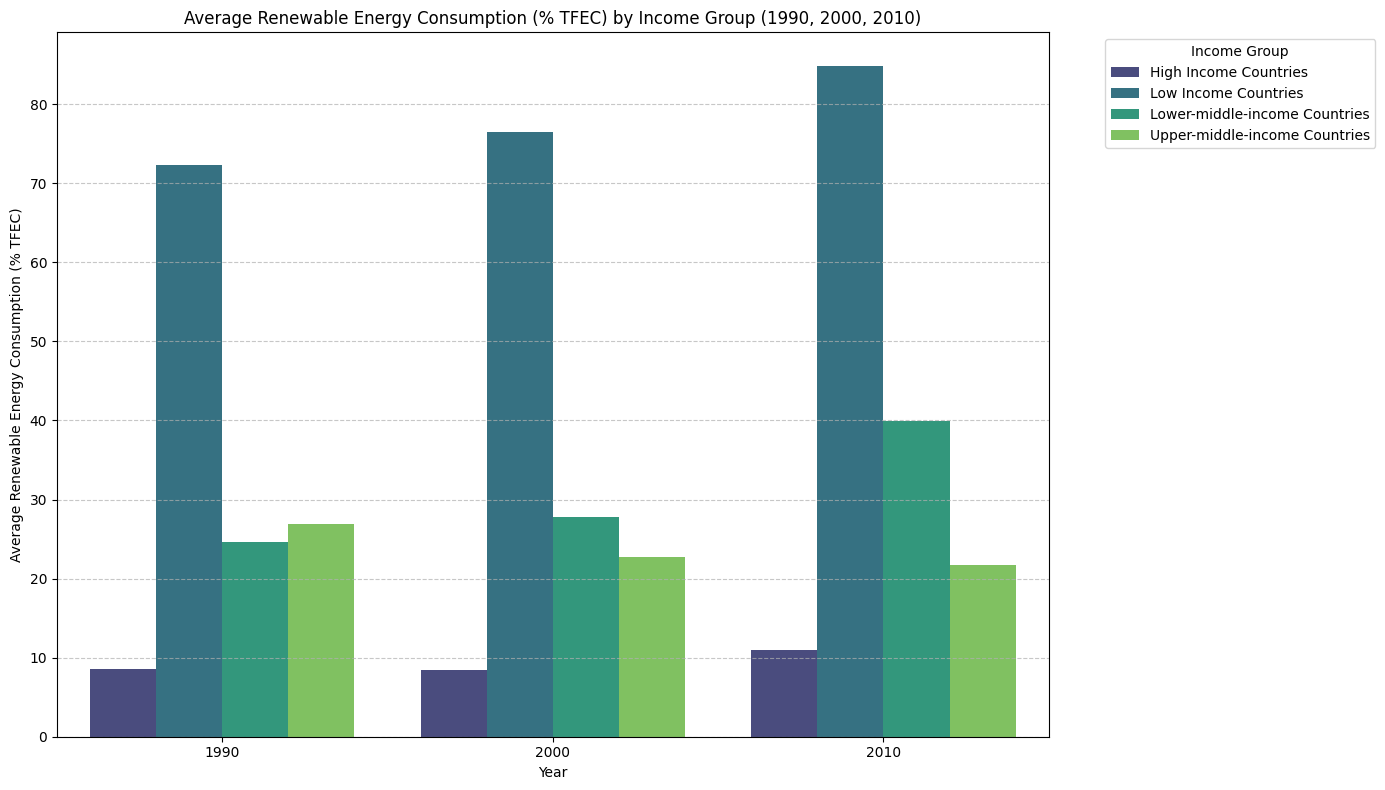

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame for the years of interest
years_to_plot = [1990, 2000, 2010]
plot_data = final_combined_df_with_gdp[final_combined_df_with_gdp['yr'].isin(years_to_plot)].copy()

# Exclude 'Not Classified' income groups for clear visualization
plot_data = plot_data[plot_data['income_group'] != 'Not Classified']

# Calculate the mean renewable energy consumption for each income group per year
average_renewable_energy_by_income_year = plot_data.groupby(['yr', 'income_group'])['renewable_energy_consumption_tfec_pct'].mean().reset_index()

# Create the bar plot
plt.figure(figsize=(14, 8))
sns.barplot(
    x='yr',
    y='renewable_energy_consumption_tfec_pct',
    hue='income_group',
    data=average_renewable_energy_by_income_year,
    palette='viridis'
)

plt.title('Average Renewable Energy Consumption (% TFEC) by Income Group (1990, 2000, 2010)')
plt.xlabel('Year')
plt.ylabel('Average Renewable Energy Consumption (% TFEC)')
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [62]:
print('--- Correlation between GDP per capita and Renewable Energy Consumption by Income Group ---')

# Calculate correlation coefficients for each income group
correlation_by_income_group = final_combined_df_with_gdp.groupby('income_group')[['gdpPerCapital_usd', 'renewable_energy_consumption_tfec_pct']].corr().unstack().iloc[:, 1]

# Rename the series for better readability
correlation_by_income_group = correlation_by_income_group.rename('Correlation (GDP vs. Renewable Energy)')

display(correlation_by_income_group)

--- Correlation between GDP per capita and Renewable Energy Consumption by Income Group ---


,Correlation (GDP vs. Renewable Energy)
income_group,
High Income Countries,-0.297348
Low Income Countries,-0.641722
Lower-middle-income Countries,-0.369386
Upper-middle-income Countries,-0.309523


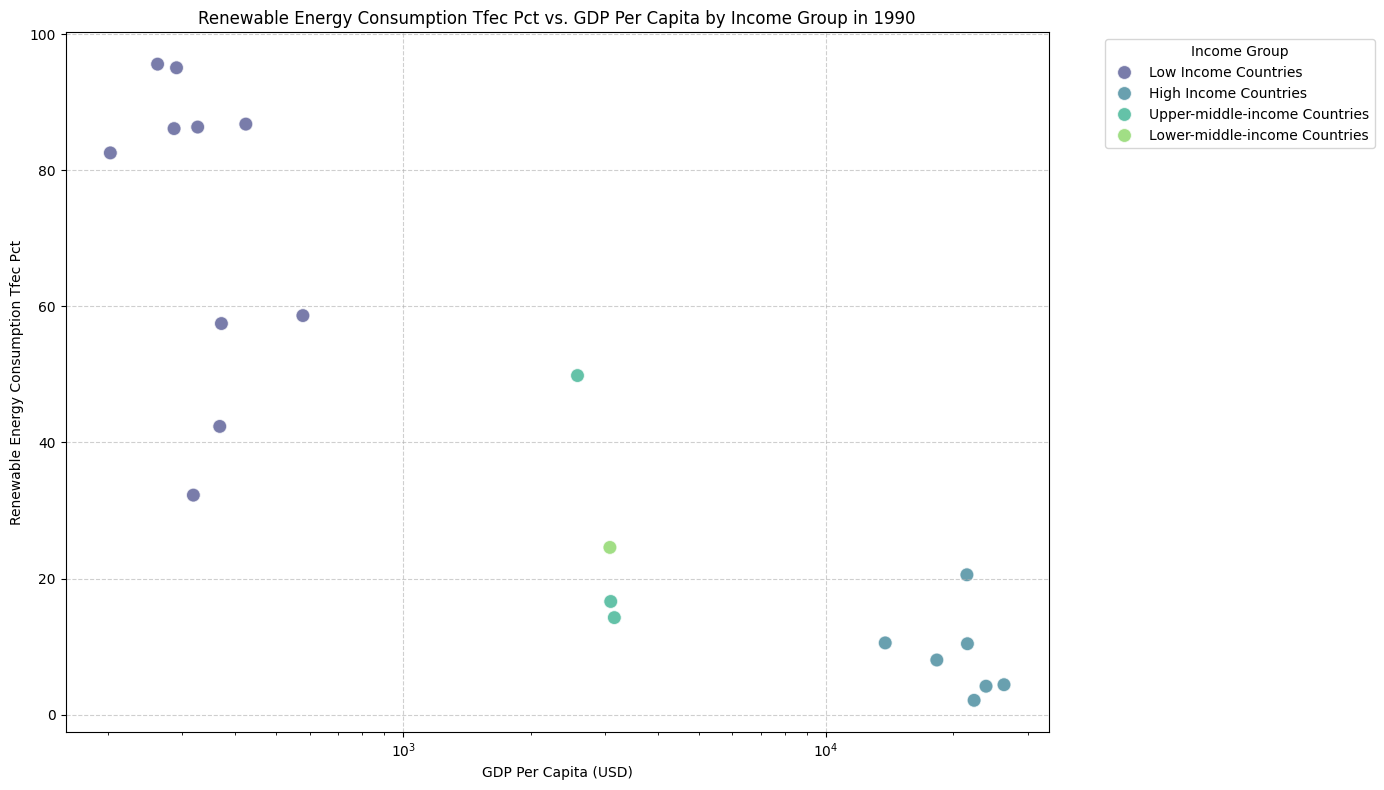

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the energy source that I want to use
energy_source_col = 'renewable_energy_consumption_tfec_pct'

# Filter for the specific year of interest (1990)
data_for_plot_1990 = final_combined_df_with_gdp[
    final_combined_df_with_gdp['yr'] == 1990
].copy()

# Drop rows where the chosen energy source or income_group is NaN for a cleaner
# visualization. We use 'gdpPerCapital_usd' which has imputed values.
data_for_plot_1990.dropna(subset=[energy_source_col, 'gdpPerCapital_usd', 'income_group'], inplace=True)

# Create the plot for 1990
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=data_for_plot_1990,
    x='gdpPerCapital_usd',
    y=energy_source_col,
    hue='income_group',
    s = 100,
    palette='viridis',
    alpha=0.7
)

plt.title(f'{energy_source_col.replace("_", " ").title()} vs. GDP Per Capita by Income Group in 1990')
plt.xlabel('GDP Per Capita (USD)')
plt.ylabel(f'{energy_source_col.replace("_", " ").title()}')
plt.xscale('log') # GDP often spans several orders of magnitude, so a log scale is useful
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

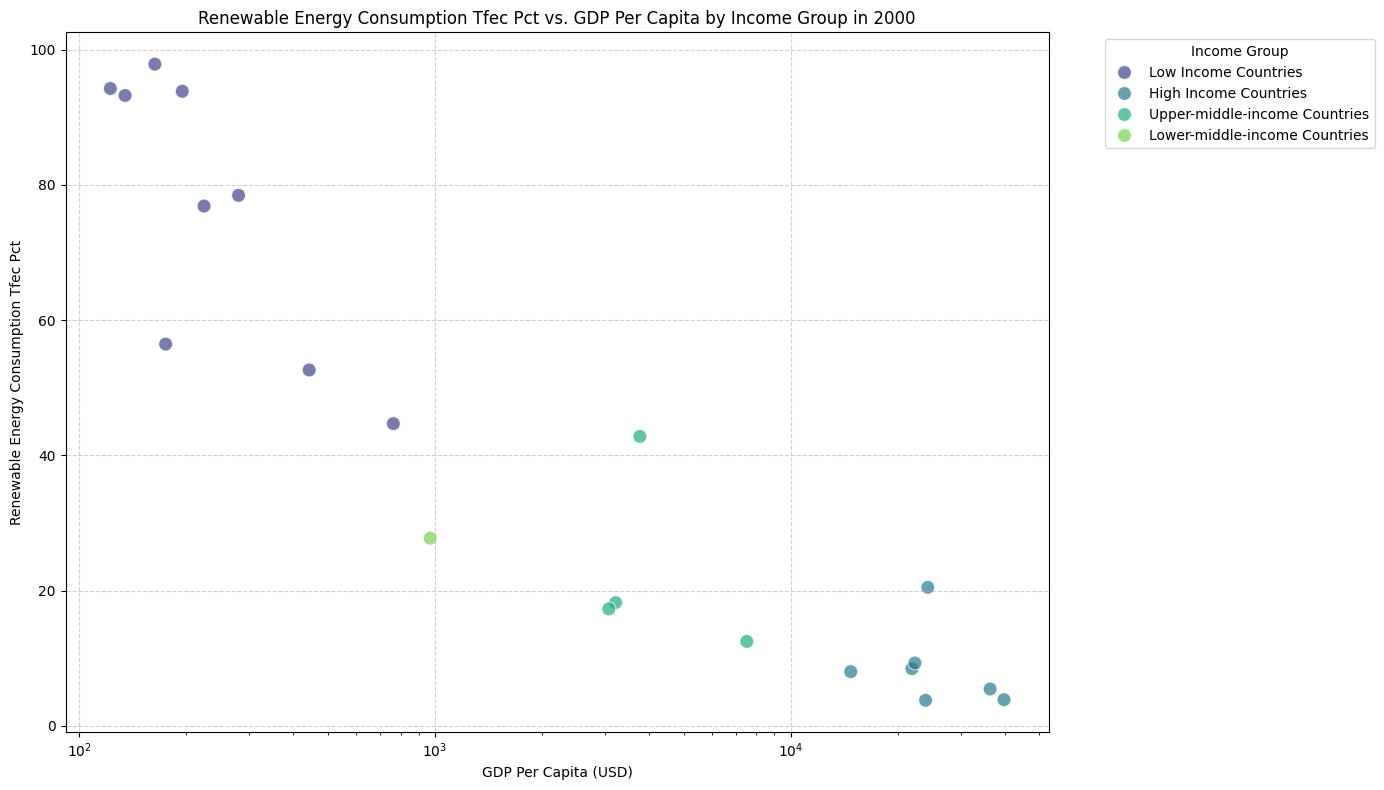

In [60]:
energy_source_col = 'renewable_energy_consumption_tfec_pct'

# Filter for the specific year of interest (2000)
data_for_plot_2000 = final_combined_df_with_gdp[
    final_combined_df_with_gdp['yr'] == 2000
].copy()

# Drop rows where the chosen energy source or income_group is NaN for a cleaner
# visualization. We use 'gdpPerCapital_usd' which has imputed values.
data_for_plot_2000.dropna(subset=[energy_source_col, 'gdpPerCapital_usd', 'income_group'], inplace=True)

# Create the plot for 2000
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=data_for_plot_2000,
    x='gdpPerCapital_usd',
    y=energy_source_col,
    hue='income_group',
    s = 100,
    palette='viridis',
    alpha=0.7
)

plt.title(f'{energy_source_col.replace("_", " ").title()} vs. GDP Per Capita by Income Group in 2000')
plt.xlabel('GDP Per Capita (USD)')
plt.ylabel(f'{energy_source_col.replace("_", " ").title()}')
plt.xscale('log') # GDP often spans several orders of magnitude, so a log scale is useful
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

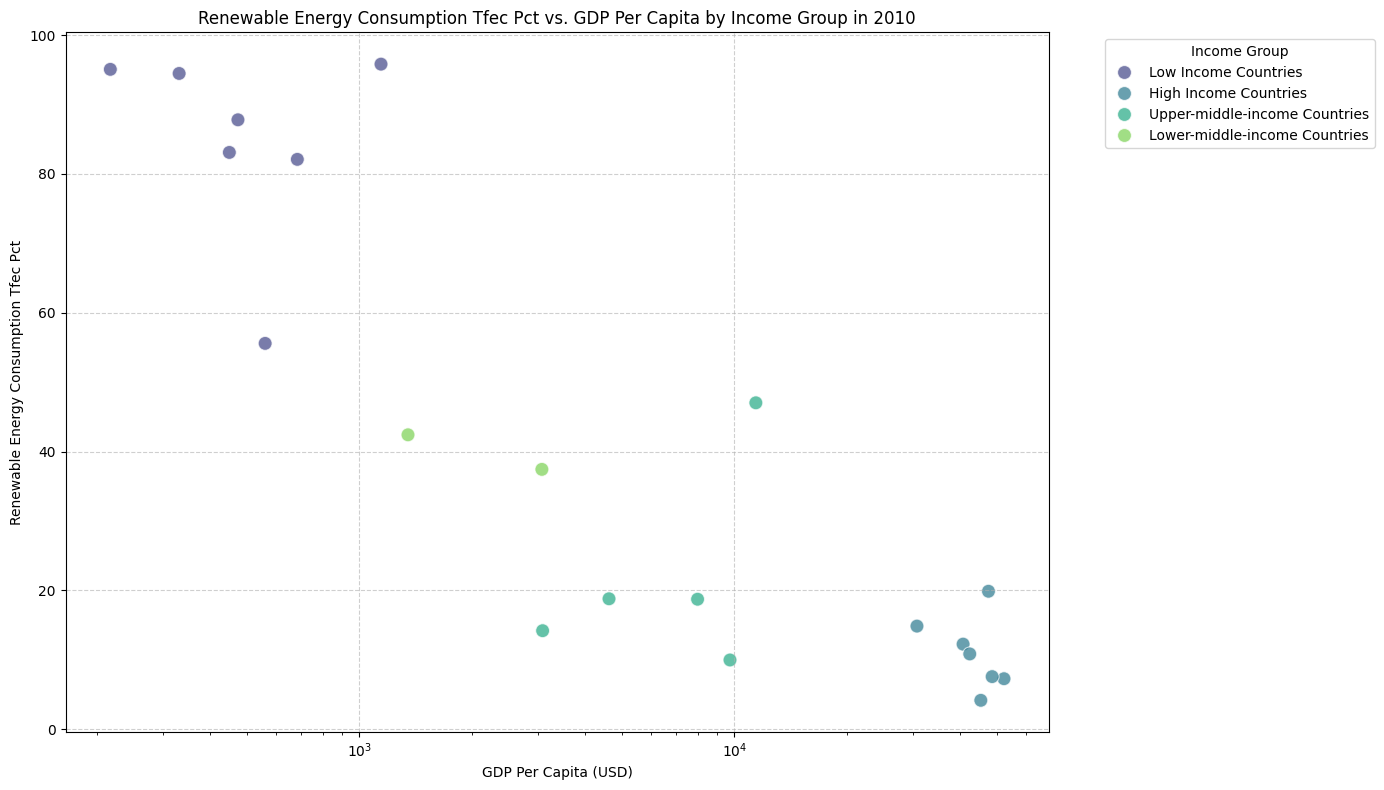

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for the specific year of interest (2010)
data_for_plot_2010 = final_combined_df_with_gdp[
    final_combined_df_with_gdp['yr'] == 2010
].copy()

# Drop rows where the chosen energy source or income_group is NaN for cleaner visualization.
# We use 'gdpPerCapital_usd' which has imputed values.
data_for_plot_2010.dropna(subset=[energy_source_col, 'gdpPerCapital_usd', 'income_group'], inplace=True)

# Create the plot for 2010
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=data_for_plot_2010,
    x='gdpPerCapital_usd',
    y=energy_source_col,
    hue='income_group',
    palette='viridis',
    s = 100,
    alpha=0.7

)

plt.title(f'{energy_source_col.replace("_", " ").title()} vs. GDP Per Capita by Income Group in 2010')
plt.xlabel('GDP Per Capita (USD)')
plt.ylabel(f'{energy_source_col.replace("_", " ").title()}')
plt.xscale('log') # GDP often spans several orders of magnitude, so a log scale is useful
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [55]:
print("### Countries in Final Combined DataFrame by Income Group (Years 1990, 2000, 2010) ###")

for year in [1990, 2000, 2010]:
    print(f"\n--- Year: {year} ---")
    df_year = final_combined_df_with_gdp[final_combined_df_with_gdp['yr'] == year]

    # Get unique countries and their income groups for the current year
    countries_by_income_group = df_year[['income_group', 'country_name']].drop_duplicates().sort_values(by=['income_group', 'country_name'])

    for income_group_name in countries_by_income_group['income_group'].unique():
        countries_in_group = countries_by_income_group[countries_by_income_group['income_group'] == income_group_name]['country_name'].tolist()
        print(f"\n{income_group_name}: ({len(countries_in_group)} countries)")
        for country in countries_in_group:
            print(f"  - {country}")

### Countries in Final Combined DataFrame by Income Group (Years 1990, 2000, 2010) ###

--- Year: 1990 ---

High Income Countries: (7 countries)
  - Australia
  - Canada
  - France
  - Germany
  - Japan
  - Spain
  - United States

Low Income Countries: (10 countries)
  - Afghanistan
  - Burundi
  - Chad
  - China
  - Ethiopia
  - India
  - Indonesia
  - Madagascar
  - Malawi
  - Niger

Lower-middle-income Countries: (1 countries)
  - Turkey

Upper-middle-income Countries: (3 countries)
  - Brazil
  - Mexico
  - South Africa

--- Year: 2000 ---

High Income Countries: (7 countries)
  - Australia
  - Canada
  - France
  - Germany
  - Japan
  - Spain
  - United States

Low Income Countries: (9 countries)
  - Afghanistan
  - Burundi
  - Chad
  - Ethiopia
  - India
  - Indonesia
  - Madagascar
  - Malawi
  - Niger

Lower-middle-income Countries: (1 countries)
  - China

Upper-middle-income Countries: (4 countries)
  - Brazil
  - Mexico
  - South Africa
  - Turkey

--- Year: 2010 ---

High 

### Step 1: Provide the URL for Income Classification Data



In [290]:
# Define the URL for the income classification data
income_URL = 'https://raw.githubusercontent.com/MarcelAvgCSCoder/SYEP-Frontier-Technology-Institute-Sustainable-Energy/refs/heads/main/world-bank-income-groups.csv'

try:
    income_df = pd.read_csv(income_URL)
    print("Income data loaded successfully.")
    display(income_df.head())
except Exception as e:
    print(f"Error loading income data: {e}")
    print("Please ensure the URL is correct and the data format is compatible (e.g., CSV).")
    income_df = pd.DataFrame()

Income data loaded successfully.


,Entity,Code,Year,World Bank's income classification
0,Afghanistan,AFG,1990,Low-income countries
1,Afghanistan,AFG,1991,Low-income countries
2,Afghanistan,AFG,1992,Low-income countries
3,Afghanistan,AFG,1993,Low-income countries
4,Afghanistan,AFG,1994,Low-income countries


### Step 2: Prepare the Income Data

This step involves cleaning and preparing the newly loaded income data (`income_df`) to ensure its columns match those in `final_combined_df_with_gdp` for a successful merge. You might need to rename columns, adjust country names, or filter by relevant years.

In [291]:
# Example: Assuming 'Entity', 'Year', and 'World Bank's income classification' are the relevant columns in income_df
# You might need to adjust these column names based on your actual income data

print("Original income_df columns:")
print(income_df.columns)

# Rename columns for consistency (adjust as needed based on your income_df)
# Based on the actual columns, these are the correct renames:
income_df = income_df.rename(columns={'Entity': 'country_name', 'Year': 'yr', "World Bank's income classification": 'income_group_new'})

# Ensure 'yr' column is numeric if it's not already
if 'yr' in income_df.columns:
    income_df['yr'] = pd.to_numeric(income_df['yr'], errors='coerce')
    income_df.dropna(subset=['yr'], inplace=True) # Drop rows where year couldn't be converted
    income_df['yr'] = income_df['yr'].astype(int)

# Apply the same country name mapping to the income_df if necessary
# (Assuming geo_country_name_mapping is already defined in a previous cell)
if 'country_name' in income_df.columns and 'geo_country_name_mapping' in globals():
    income_df['country_name'] = income_df['country_name'].replace(geo_country_name_mapping)

# Filter income_df to only include years present in final_combined_df_with_gdp if needed
# relevant_years = final_combined_df_with_gdp['yr'].unique()
# income_df = income_df[income_df['yr'].isin(relevant_years)]

print("Prepared income data head:")
display(income_df.head())

Original income_df columns:
Index(['Entity', 'Code', 'Year', 'World Bank's income classification'], dtype='object')
Prepared income data head:


,country_name,Code,yr,income_group_new
0,Afghanistan,AFG,1990,Low-income countries
1,Afghanistan,AFG,1991,Low-income countries
2,Afghanistan,AFG,1992,Low-income countries
3,Afghanistan,AFG,1993,Low-income countries
4,Afghanistan,AFG,1994,Low-income countries


### Step 3: Update `income_group` in `final_combined_df_with_gdp`

Now, we'll merge the `final_combined_df_with_gdp` with the prepared `income_df` to fill in the `income_group` for countries previously marked as 'Not Classified'.

In [292]:
# Create a temporary copy to avoid modifying original df during merge check
merged_temp_df = final_combined_df_with_gdp.copy()

# Apply the geographical country name mapping to both final_combined_df_with_gdp and merged_temp_df's country_name
# to ensure consistency with income_df before merging
if 'geo_country_name_mapping' in globals():
    final_combined_df_with_gdp['country_name'] = final_combined_df_with_gdp['country_name'].replace(geo_country_name_mapping)
    merged_temp_df['country_name'] = merged_temp_df['country_name'].replace(geo_country_name_mapping)

# Perform a left merge to bring in the new income classifications
# The merge columns should be 'country_name' and 'yr'
merged_temp_df = pd.merge(
    merged_temp_df,
    income_df[['country_name', 'yr', 'income_group_new']],
    on=['country_name', 'yr'],
    how='left'
)

# Update 'income_group' where it is 'Not Classified' using the new data
# Make sure the 'Not Classified' string matches exactly
final_combined_df_with_gdp['income_group'] = merged_temp_df.apply(
    lambda row: row['income_group_new'] if (row['income_group'] == 'Not Classified' and pd.notna(row['income_group_new']))
    else row['income_group'],
    axis=1
)

# The temporary column 'income_group_new' from merged_temp_df is not directly added to final_combined_df_with_gdp
# and merged_temp_df is a temporary variable, so no explicit drop is needed for final_combined_df_with_gdp.
# Removed the old 'if' block which was checking for 'income_group_from_new_data'.

print("Updated `final_combined_df_with_gdp` head with new income classifications:")
display(final_combined_df_with_gdp.head())

# Verify the update for 'United States' for instance
print("United States income_group after update (should be classified if data was provided):")
display(final_combined_df_with_gdp[
    (final_combined_df_with_gdp['country_name'] == 'United States of America') & # Check for the mapped name
    (final_combined_df_with_gdp['yr'].isin([1990, 2000, 2010]))
][['country_name', 'yr', 'income_group']].drop_duplicates())

print("Summary of income groups after update:")
for year in [1990, 2000, 2010]:
    print(f"\n--- Year: {year} ---")
    df_year = final_combined_df_with_gdp[final_combined_df_with_gdp['yr'] == year]
    countries_by_income_group = df_year[['income_group', 'country_name']].drop_duplicates().sort_values(by=['income_group', 'country_name'])
    for income_group_name in countries_by_income_group['income_group'].unique():
        countries_in_group = countries_by_income_group[countries_by_income_group['income_group'] == income_group_name]['country_name'].tolist()
        print(f"\n{income_group_name}: ({len(countries_in_group)} countries)")
        for country in countries_in_group:
            print(f"  - {country}")

Updated `final_combined_df_with_gdp` head with new income classifications:


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group,gdp_usd,gdpPerCapital_usd
0,Afghanistan,1990,0.00725,0.0,0.0,10.195503,42.362380,9661.83210,Low-income countries,NaN,367.776248
1,Afghanistan,1991,0.00725,0.0,0.0,9.545578,44.062889,9229.66245,Low-income countries,NaN,367.776248
2,Afghanistan,1992,0.00725,0.0,0.0,8.981214,50.784306,8012.85660,Low-income countries,NaN,367.776248
3,Afghanistan,1993,0.00725,0.0,0.0,17.009797,54.716233,9402.11415,Low-income countries,NaN,367.776248
4,Afghanistan,1994,0.00725,0.0,0.0,16.760214,56.525081,9444.70035,Low-income countries,NaN,367.776248


United States income_group after update (should be classified if data was provided):


,country_name,yr,income_group
420,United States of America,1990,High-income countries
430,United States of America,2000,High-income countries
440,United States of America,2010,High-income countries


Summary of income groups after update:

--- Year: 1990 ---

High-income countries: (7 countries)
  - Australia
  - Canada
  - France
  - Germany
  - Japan
  - Spain
  - United States of America

Low-income countries: (10 countries)
  - Afghanistan
  - Burundi
  - Chad
  - China
  - Ethiopia
  - India
  - Indonesia
  - Madagascar
  - Malawi
  - Niger

Lower-middle-income Countries: (1 countries)
  - Turkey

Upper-middle-income Countries: (3 countries)
  - Brazil
  - Mexico
  - South Africa

--- Year: 2000 ---

High-income countries: (7 countries)
  - Australia
  - Canada
  - France
  - Germany
  - Japan
  - Spain
  - United States of America

Low-income countries: (9 countries)
  - Afghanistan
  - Burundi
  - Chad
  - Ethiopia
  - India
  - Indonesia
  - Madagascar
  - Malawi
  - Niger

Lower-middle-income Countries: (1 countries)
  - China

Upper-middle-income Countries: (4 countries)
  - Brazil
  - Mexico
  - South Africa
  - Turkey

--- Year: 2010 ---

High-income countries: (7 count

In [284]:
print("Checking income_df for 'United States' entries for years 1990, 2000, 2010:")
display(income_df[
    (income_df['country_name'] == 'United States') &
    (income_df['yr'].isin([1990, 2000, 2010]))
])

print("Also checking for 'United States of America' in case it was mapped by chance:")
display(income_df[
    (income_df['country_name'] == 'United States of America') &
    (income_df['yr'].isin([1990, 2000, 2010]))
])

print("If the above shows no results, you might need to check other possible names for the US in income_df.head() or the original CSV file.")

Checking income_df for 'United States' entries for years 1990, 2000, 2010:


,country_name,Code,yr,income_group_new


Also checking for 'United States of America' in case it was mapped by chance:


,country_name,Code,yr,income_group_new
4171,United States of America,USA,1990,High-income countries
4181,United States of America,USA,2000,High-income countries
4191,United States of America,USA,2010,High-income countries


If the above shows no results, you might need to check other possible names for the US in income_df.head() or the original CSV file.


### World Map Visualization of Countries by Income Group (1990, 2000, 2010)


--- Generating map for year: 1990 ---
  DEBUG: 'United States' found in data_for_map before mapping for 1990.
      country_name           income_group
420  United States  High Income Countries
  DEBUG: 'United States of America' found in data_for_map after mapping for 1990.
                 country_name           income_group
420  United States of America  High Income Countries
  DEBUG: 'United States of America' MERGED. Income Group: High Income Countries


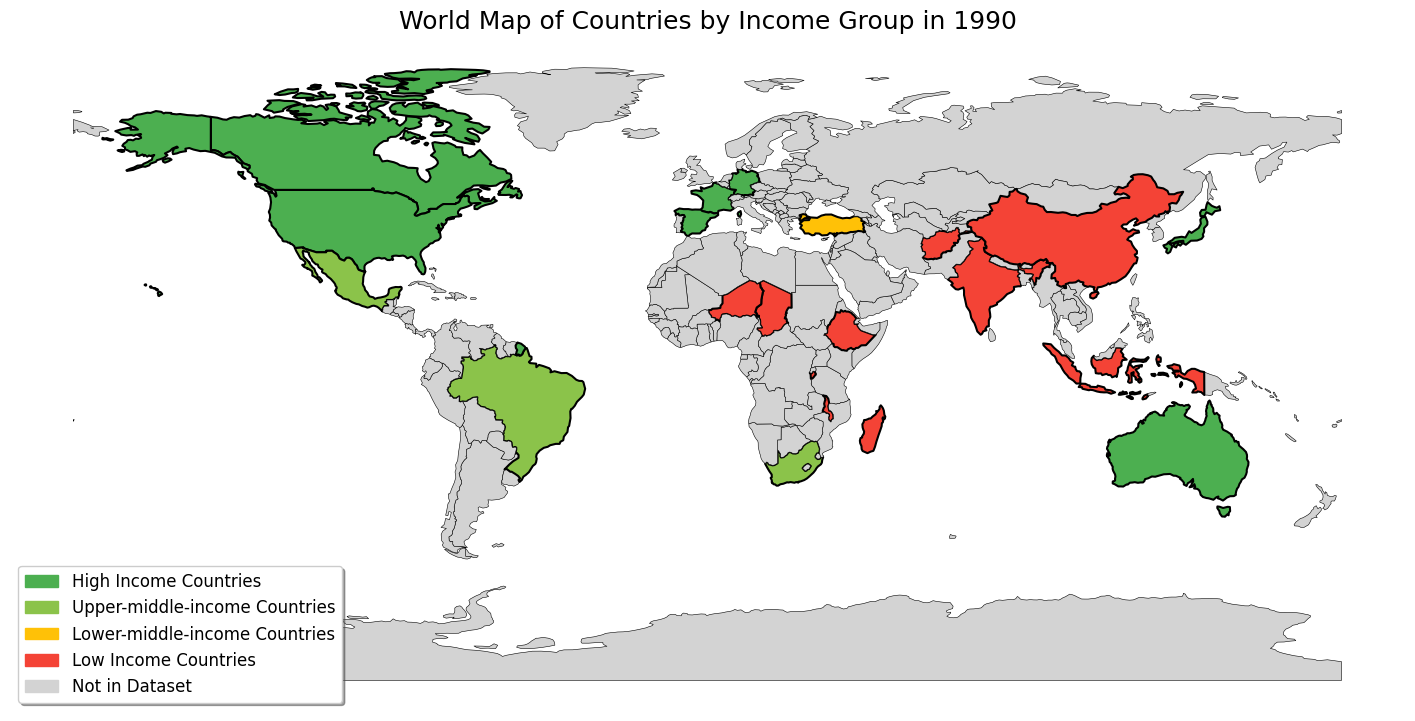


--- Generating map for year: 2000 ---
  DEBUG: 'United States' found in data_for_map before mapping for 2000.
      country_name           income_group
430  United States  High Income Countries
  DEBUG: 'United States of America' found in data_for_map after mapping for 2000.
                 country_name           income_group
430  United States of America  High Income Countries
  DEBUG: 'United States of America' MERGED. Income Group: High Income Countries


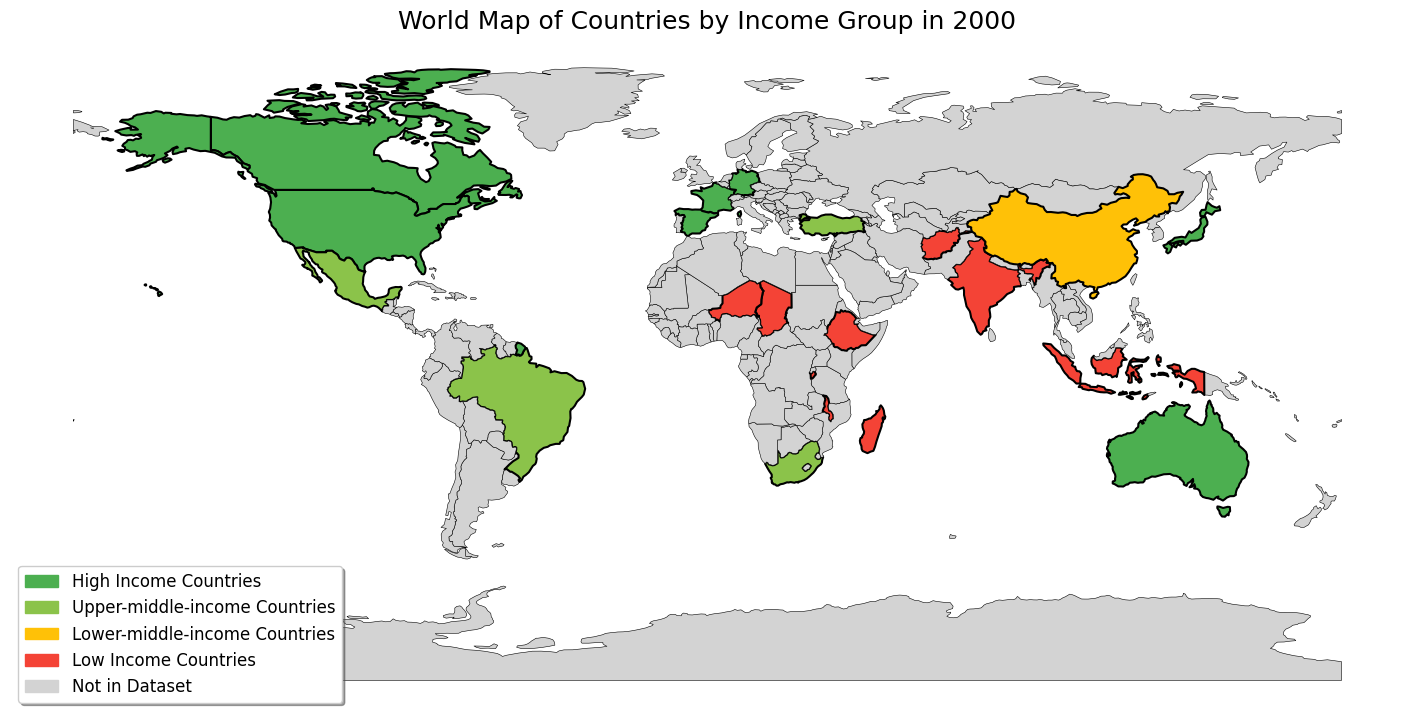


--- Generating map for year: 2010 ---
  DEBUG: 'United States' found in data_for_map before mapping for 2010.
      country_name           income_group
440  United States  High Income Countries
  DEBUG: 'United States of America' found in data_for_map after mapping for 2010.
                 country_name           income_group
440  United States of America  High Income Countries
  DEBUG: 'United States of America' MERGED. Income Group: High Income Countries


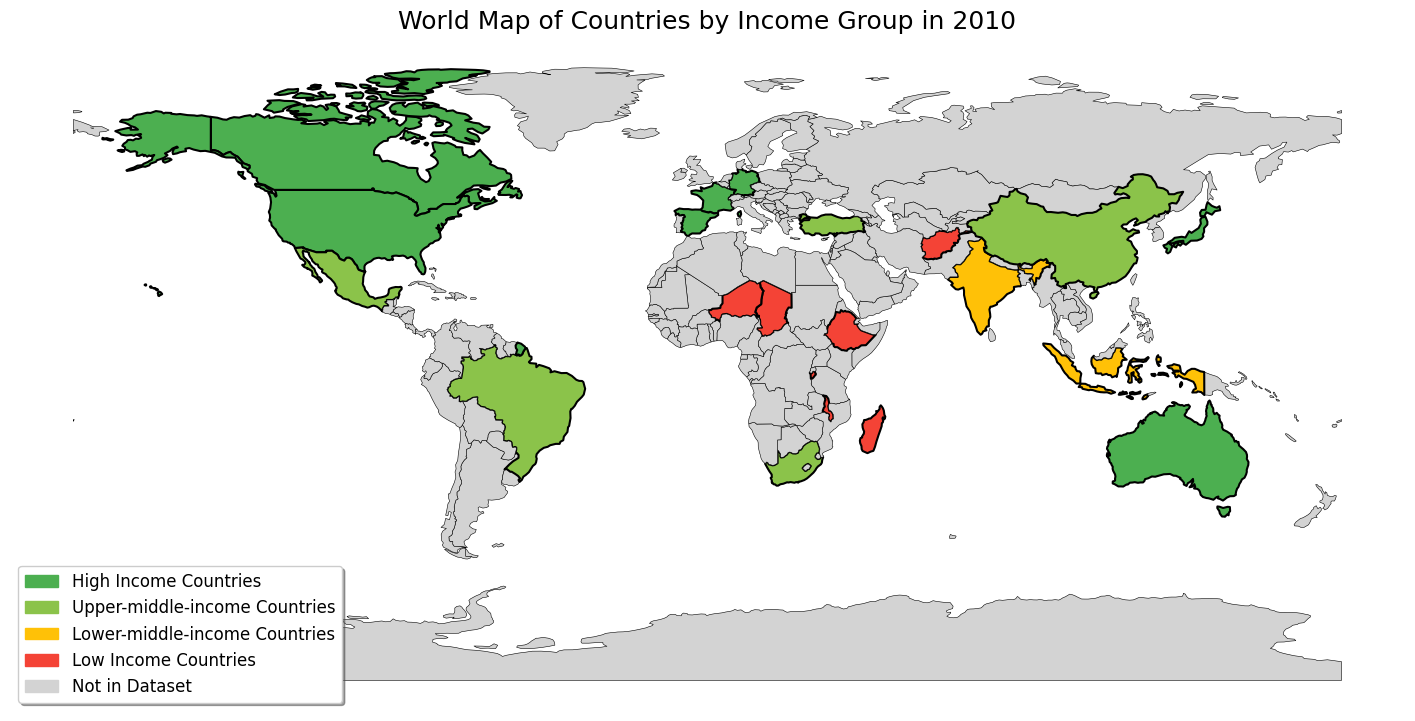

In [50]:
import geopandas as gpd
import matplotlib.pyplot as plt
import requests, zipfile, io
import pandas as pd
import matplotlib.patches as mpatches

# Redefine the income group color map for better clarity
# Corrected to match the income group names from final_combined_df_with_gdp
income_color_map = {
    'High Income Countries': '#4CAF50', # Green
    'Upper-middle-income Countries': '#8BC34A', # Light Green
    'Lower-middle-income Countries': '#FFC107', # Amber
    'Low Income Countries': '#F44336' # Red
}

# List of years to generate maps for
years_to_map = [1990, 2000, 2010]

# Download and load Natural Earth shapefile (Admin 0 Countries) if not already done
# (This code block is repeated here for self-containment, but ideally, this would be in a setup cell)
if 'world' not in locals(): # Check if 'world' GeoDataFrame exists
    url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall("ne_countries")
    world = gpd.read_file("ne_countries/ne_110m_admin_0_countries.shp")

# Define a mapping for country names in our data to match Natural Earth names
# This is crucial for correct merging with the geographical data
geo_country_name_mapping = {
    'United States': 'United States of America',
    'South Korea': 'Republic of Korea',
    'Hong Kong': 'Hong Kong S.A.R.',
    'Egypt': 'Egypt',
    'Russia': 'Russian Federation',
    'Congo, Dem. Rep.': 'Democratic Republic of the Congo',
    'Congo, Rep.': 'Republic of the Congo',
    'Myanmar': 'Myanmar',
    'Slovak Republic': 'Slovakia',
    'Kyrgyz Republic': 'Kyrgyzstan',
    'Iran, Islamic Rep.': 'Iran',
    'Venezuela, RB': 'Venezuela',
    'Yemen, Rep.': 'Yemen',
    'Bahamas, The': 'The Bahamas',
    'Timor-Leste': 'East Timor',
    # Ensuring all final_selected_countries are explicitly mapped if names differ in world GeoDataFrame
    'Afghanistan': 'Afghanistan',
    'Australia': 'Australia',
    'Brazil': 'Brazil',
    'Burundi': 'Burundi',
    'Canada': 'Canada',
    'Chad': 'Chad',
    'China': 'China', # Adding China to mapping
    'Ethiopia': 'Ethiopia',
    'France': 'France',
    'Germany': 'Germany', # Adding Germany to mapping
    'India': 'India', # Adding India to mapping
    'Indonesia': 'Indonesia', # Adding Indonesia to mapping
    'Japan': 'Japan',
    'Madagascar': 'Madagascar',
    'Malawi': 'Malawi',
    'Mexico': 'Mexico', # Adding Mexico to mapping
    'Niger': 'Niger',
    'South Africa': 'South Africa', # Adding South Africa to mapping
    'Spain': 'Spain',
    'Turkey': 'Turkey' # Adding Turkey to mapping
}

# Iterate through each year and create a map
for year in years_to_map:
    print(f"\n--- Generating map for year: {year} ---")

    # Filter final_combined_df_with_gdp for the current year and relevant columns
    data_for_map = final_combined_df_with_gdp[
        final_combined_df_with_gdp['yr'] == year
    ][['country_name', 'income_group']].drop_duplicates().copy()

    # DEBUG: Check 'United States' before mapping
    us_before_map = data_for_map[data_for_map['country_name'] == 'United States']
    if not us_before_map.empty:
        print(f"  DEBUG: 'United States' found in data_for_map before mapping for {year}.")
        print(us_before_map)
    else:
        print(f"  DEBUG: 'United States' NOT found in data_for_map before mapping for {year}.")

    # Apply the geographical country name mapping to our data
    data_for_map['country_name'] = data_for_map['country_name'].replace(geo_country_name_mapping)

    # DEBUG: Check 'United States of America' after mapping
    usa_after_map = data_for_map[data_for_map['country_name'] == 'United States of America']
    if not usa_after_map.empty:
        print(f"  DEBUG: 'United States of America' found in data_for_map after mapping for {year}.")
        print(usa_after_map)
    else:
        print(f"  DEBUG: 'United States of America' NOT found in data_for_map after mapping for {year}.")

    # Merge with world map GeoDataFrame
    # Use 'NAME' from world GeoDataFrame and 'country_name' from our data
    merged_map_data = world.merge(data_for_map, how="left", left_on="NAME", right_on="country_name")

    # DEBUG: Check if 'United States of America' merged successfully and has an income_group
    usa_merged = merged_map_data[merged_map_data['NAME'] == 'United States of America']
    if not usa_merged.empty:
        print(f"  DEBUG: 'United States of America' MERGED. Income Group: {usa_merged['income_group'].iloc[0]}")
    else:
        print(f"  DEBUG: 'United States of America' DID NOT MERGE or lost during merge.")

    # Map income_group to colors. Countries not in our data will be 'Not in Dataset' or grey.
    merged_map_data['color'] = merged_map_data['income_group'].map(income_color_map).fillna('#D3D3D3') # Grey for 'Not in Dataset' or 'Not Classified'

    # Define linewidth: bolder for countries present in `data_for_map`, thinner for others
    # Also, ensure 'Not Classified' countries are treated as 'Not in Dataset' for border purposes
    merged_map_data['border_linewidth'] = merged_map_data.apply(lambda row: 1.5 if pd.notna(row['country_name']) and row['income_group'] != 'Not Classified' else 0.4, axis=1)

    # Plotting
    fig, ax = plt.subplots(1, 1, figsize=(18, 10))
    merged_map_data.plot(color=merged_map_data['color'], edgecolor="black", linewidth=merged_map_data['border_linewidth'], ax=ax)

    ax.set_title(f'World Map of Countries by Income Group in {year}', fontsize=18)
    ax.set_axis_off() # Remove axes

    # Create a custom legend
    legend_patches = []
    for group, color in income_color_map.items():
        legend_patches.append(mpatches.Patch(color=color, label=group))
    legend_patches.append(mpatches.Patch(color='#D3D3D3', label='Not in Dataset'))

    ax.legend(handles=legend_patches, loc='lower left', fontsize=12, frameon=True, fancybox=True, shadow=True)

    plt.show()

In [41]:
from sklearn.metrics import mean_absolute_error

# Calculate MAE on the original scale
mae_original_scale = mean_absolute_error(y_test_original_scale, y_pred_original_scale)

print(f"Mean Absolute Error on original scale: {mae_original_scale:.4f}")

Mean Absolute Error on original scale: 13.8724


In [262]:
print("United States entries in final_combined_df_with_gdp for 1990, 2000, 2010:")
display(final_combined_df_with_gdp[final_combined_df_with_gdp['country_name'] == 'United States'])

print("South American countries entries (e.g., Brazil) in final_combined_df_with_gdp for 1990, 2000, 2010:")
display(final_combined_df_with_gdp[final_combined_df_with_gdp['country_name'] == 'Brazil'])

United States entries in final_combined_df_with_gdp for 1990, 2000, 2010:


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group,gdp_usd,gdpPerCapital_usd
420,United States,1990,0.018461,0.125015,0.004010,1.644670,4.175462,49172282.0,Not Classified,23888.60001,23888.60001
421,United States,1991,0.019009,0.131109,0.004872,1.795620,4.507919,49234551.0,Not Classified,NaN,36329.97026
422,United States,1992,0.018007,0.136173,0.004624,1.570253,4.763083,49497730.0,Not Classified,NaN,36329.97026
423,United States,1993,0.018465,0.138296,0.005449,1.713446,4.281529,50431569.0,Not Classified,NaN,36329.97026
424,United States,1994,0.020889,0.136743,0.004966,1.575894,4.088642,51418451.0,Not Classified,NaN,36329.97026
425,United States,1995,0.018996,0.121624,0.004921,1.866991,4.726553,51788445.0,Not Classified,NaN,36329.97026
426,United States,1996,0.019733,0.123554,0.005243,2.030715,4.763932,53304914.0,Not Classified,NaN,36329.97026
427,United States,1997,0.018795,0.119274,0.005181,1.924372,4.514261,53885418.0,Not Classified,NaN,36329.97026
428,United States,1998,0.017362,0.122611,0.005120,1.703352,4.534295,53983232.0,Not Classified,NaN,36329.97026
429,United States,1999,0.026955,0.124707,0.117303,1.559997,5.709727,55803532.0,Not Classified,NaN,36329.97026


South American countries entries (e.g., Brazil) in final_combined_df_with_gdp for 1990, 2000, 2010:


,country_name,yr,wind_energy_consumption_tfec_pct,geothermal_energy_consumption_tfec_pct,solar_energy_consumption_tfec_pct,hydro_energy_consumption_tfec_pct,renewable_energy_consumption_tfec_pct,total_final_energy_consumption_tfec,income_group,gdp_usd,gdpPerCapital_usd
42,Brazil,1990,0.003218,0.0,0.000000,16.492729,49.834827,4269739.000,Upper-middle-income Countries,2581.141874,2581.141874
43,Brazil,1991,0.003218,0.0,0.000000,16.726852,48.850231,4352339.000,Upper-middle-income Countries,NaN,3766.548115
44,Brazil,1992,0.003218,0.0,0.000000,16.768861,48.613560,4416153.000,Upper-middle-income Countries,NaN,3766.548115
45,Brazil,1993,0.003218,0.0,0.000000,17.251554,48.106500,4541131.000,Upper-middle-income Countries,NaN,3766.548115
46,Brazil,1994,0.003218,0.0,0.045166,17.086264,48.222987,4760534.000,Upper-middle-income Countries,NaN,3766.548115
47,Brazil,1995,0.003218,0.0,0.045166,17.022026,45.997720,4998705.000,Upper-middle-income Countries,NaN,3766.548115
48,Brazil,1996,0.000126,0.0,0.045166,16.756427,44.375528,5267491.000,Upper-middle-income Countries,NaN,3766.548115
49,Brazil,1997,0.000242,0.0,0.045166,16.875951,43.622946,5518515.000,Upper-middle-income Countries,NaN,3766.548115
50,Brazil,1998,0.000292,0.0,0.045166,17.039761,43.812734,5692953.000,Upper-middle-income Countries,NaN,3766.548115
51,Brazil,1999,0.000113,0.0,0.014789,16.568477,44.039199,5808408.865,Upper-middle-income Countries,NaN,3766.548115


In [263]:
print("Unique country names in 'world' GeoDataFrame relevant to our data:")
display(world[world['NAME'].isin(['United States of America', 'Brazil'])]['NAME'].unique())

Unique country names in 'world' GeoDataFrame relevant to our data:


array(['United States of America', 'Brazil'], dtype=object)